# Stage 2 — ResNet18 wheat / non-wheat tile classifier

Original Colab notebook, kept with its outputs (comments and plot labels are in Russian).

**Dataset:** A. Maulit, A. Nugumanova, K. Apayev, Y. Baiburin, M. Sutula, *A multispectral UAV imagery dataset of wheat, soybean, and barley crops in East Kazakhstan* — Zenodo, [doi:10.5281/zenodo.7860751](https://doi.org/10.5281/zenodo.7860751) (CC BY 4.0), archive `Component2-Processed UAV Imagery.zip` (~22 GB). Paper: *Data* 2023, 8(5), 88, [doi:10.3390/data8050088](https://doi.org/10.3390/data8050088). Flights were made in the 2022 season; the "2023" in some plot titles below is a labeling slip.

**Read before quoting numbers** (details in `docs/results.md`):
- The two classes are **wheat vs soybean**. Later cells re-label soybean as "weed (strong)" and barley as "weed (weak/borderline)" for demo maps; no real weed imagery was used.
- The 99.75% validation accuracy comes from a random tile-level split: tiles from the same images are in both train and val.
- The synthetic "field" tests (cells 10, 14–16) are mosaics built from `tiles_balanced`, i.e. from the training pool, so their 100% detection is not an independent test. Barley tiles were never seen in training.
- Cell 9 (wheat plot 13, not used for training) is the closest thing to a held-out check: 97.0% of valid tiles classified as wheat on a pure-wheat plot.

In [ ]:
!wget -O /content/Component2.zip "https://zenodo.org/records/7860751/files/Component2-Processed%20UAV%20Imagery.zip?download=1"

--2026-06-01 11:51:13--  https://zenodo.org/records/7860751/files/Component2-Processed%20UAV%20Imagery.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.185.48.75, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23281774976 (22G) [application/octet-stream]
Saving to: ‘/content/Component2.zip’

/content/Component2  63%[===========>        ]  13.72G  --.-KB/s    in 17m 7s  

2026-06-01 12:08:21 (13.7 MB/s) - Connection closed at byte 14727919924. Retrying.

--2026-06-01 12:08:22--  (try: 2)  https://zenodo.org/records/7860751/files/Component2-Processed%20UAV%20Imagery.zip?download=1
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 206 PARTIAL_CONTENT
Length: 23281774976 (22G), 8553855052 (8.0G) remaining [application/octet-stream]
Saving to: ‘/content/Component2.zip’

/content/Component2  67%[++++++++++++> 

In [ ]:
!pip install rasterio

In [ ]:
import os

# Смотрим что внутри
base = '/content/dataset'

for root, dirs, files in os.walk(base):
    # Ограничиваем глубину чтобы не завалило текстом
    depth = root.replace(base, '').count(os.sep)
    if depth <= 2:
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/")
        if depth == 2:
            # На третьем уровне показываем сами файлы
            for f in files[:3]:  # только первые 3 файла
                print(f"{'  ' * (depth+1)}{f}")
            if len(files) > 3:
                print(f"{'  ' * (depth+1)}... и ещё {len(files)-3} файлов")

dataset/
  Component2-Processed UAV Imagery/
    wheat/
    barley/
    soybean/


In [ ]:
import os

wheat_path = '/content/dataset/Component2-Processed UAV Imagery/wheat'
barley_path = '/content/dataset/Component2-Processed UAV Imagery/barley'
soybean_path = '/content/dataset/Component2-Processed UAV Imagery/soybean'

print("=== WHEAT ===")
for folder in sorted(os.listdir(wheat_path))[:3]:  # первые 3 папки
    folder_full = os.path.join(wheat_path, folder)
    if os.path.isdir(folder_full):
        files = os.listdir(folder_full)
        print(f"  Папка '{folder}': {files}")

print("\n=== SOYBEAN ===")
for folder in sorted(os.listdir(soybean_path))[:3]:
    folder_full = os.path.join(soybean_path, folder)
    if os.path.isdir(folder_full):
        files = os.listdir(folder_full)
        print(f"  Папка '{folder}': {files}")

=== WHEAT ===
  Папка '10': ['10_06-21.tif', '10_05-18.tif', '10_07-12.tif', '10_06-08.tif', '10_07-25.tif']
  Папка '11': ['11_05-18.tif', '11_07-25.tif', '11_06-21.tif', '11_07-12.tif', '11_06-08.tif']
  Папка '12': ['12_07-12.tif', '12_06-21.tif', '12_06-08.tif', '12_07-25.tif', '12_05-18.tif']

=== SOYBEAN ===
  Папка '19': ['19_06-21.tif', '19_07-25.tif', '19_07-12.tif', '19_06-08.tif']
  Папка '20': ['20_06-08.tif', '20_06-21.tif', '20_07-25.tif', '20_07-12.tif']
  Папка '21': ['20_06-08.tif', '20_06-21.tif', '20_07-25.tif', '20_07-12.tif']


In [ ]:
import rasterio
import numpy as np

tiff_path = '/content/dataset/Component2-Processed UAV Imagery/wheat/10/10_05-18.tif'

with rasterio.open(tiff_path) as src:
    print("=== ИНФОРМАЦИЯ О ФАЙЛЕ ===")
    print(f"Количество каналов: {src.count}")
    print(f"Размер: {src.width} x {src.height} пикселей")
    print(f"Тип данных пикселей: {src.dtypes}")
    print(f"Описания каналов: {src.descriptions}")
    print(f"Nodata значение: {src.nodata}")

    data = src.read()  # shape: (каналы, высота, ширина)
    print(f"\nФорма массива: {data.shape}")
    print(f"\n--- Статистика по каждому каналу ---")
    for i in range(src.count):
        ch = data[i]
        valid = ch[ch != src.nodata] if src.nodata else ch.flatten()
        print(f"Канал {i+1} '{src.descriptions[i]}': "
              f"min={valid.min():.1f}, max={valid.max():.1f}, "
              f"mean={valid.mean():.1f}")

=== ИНФОРМАЦИЯ О ФАЙЛЕ ===
Количество каналов: 6
Размер: 1639 x 6095 пикселей
Тип данных пикселей: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32')
Описания каналов: (None, None, None, None, None, None)
Nodata значение: None

Форма массива: (6, 6095, 1639)

--- Статистика по каждому каналу ---
Канал 1 'None': min=4193.0, max=65535.0, mean=28020.4
Канал 2 'None': min=32.0, max=65535.0, mean=22057.5
Канал 3 'None': min=333.0, max=65535.0, mean=24568.5
Канал 4 'None': min=0.0, max=65535.0, mean=17915.6
Канал 5 'None': min=0.0, max=65535.0, mean=17550.2
Канал 6 'None': min=-1.0, max=0.7, mean=-0.1


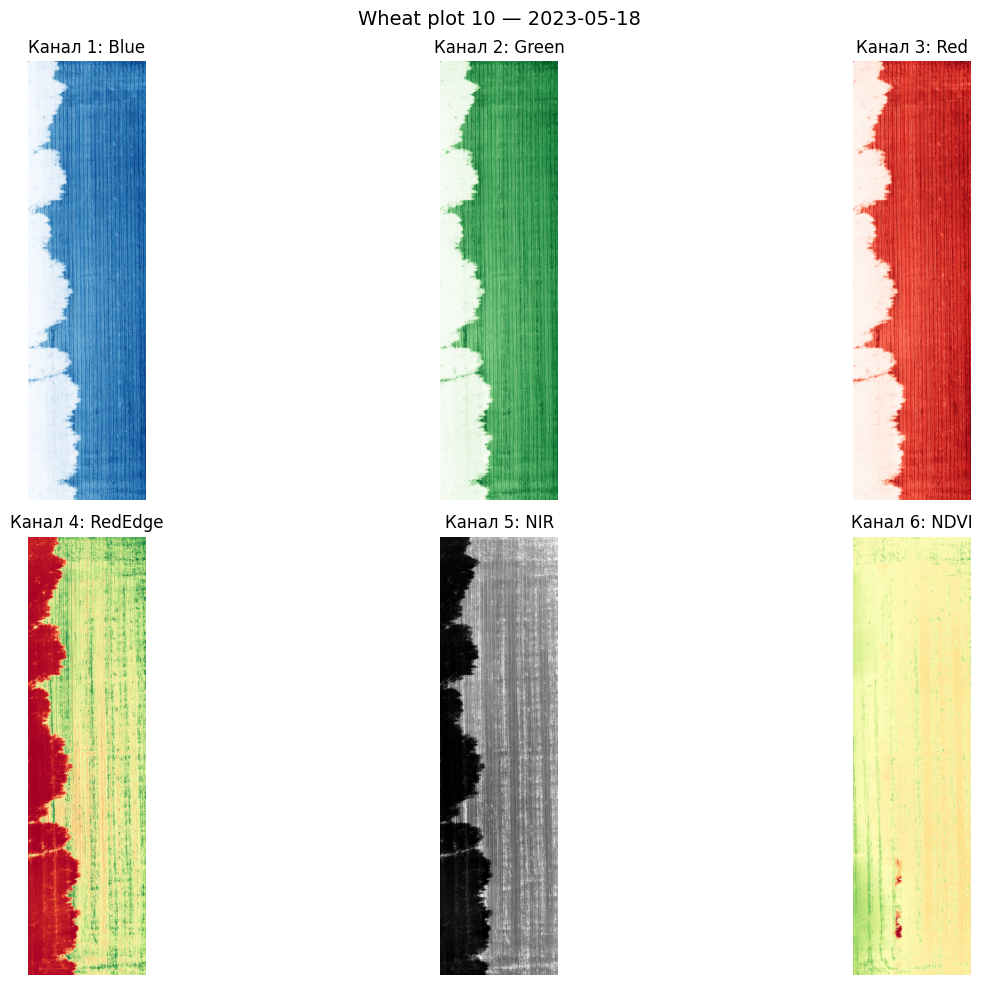

Картинка сохранена в /content/wheat_10_preview.png


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tiff_path = '/content/dataset/Component2-Processed UAV Imagery/wheat/10/10_05-18.tif'

with rasterio.open(tiff_path) as src:
    data = src.read()  # (6, H, W)

# Каналы по индексам (0-based)
# 0=Blue, 1=Green, 2=Red, 3=RedEdge, 4=NIR, 5=NDVI

def normalize(band):
    """Нормализует канал в диапазон 0-1 для отображения"""
    b = band.astype(np.float32)
    p2, p98 = np.percentile(b[b > 0], [2, 98])  # игнорируем нули
    b = np.clip(b, p2, p98)
    b = (b - p2) / (p98 - p2)
    return b

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
titles = ['Канал 1: Blue', 'Канал 2: Green', 'Канал 3: Red',
          'Канал 4: RedEdge', 'Канал 5: NIR', 'Канал 6: NDVI']
cmaps  = ['Blues', 'Greens', 'Reds', 'RdYlGn', 'gray', 'RdYlGn']

for i, (ax, title, cmap) in enumerate(zip(axes.flat, titles, cmaps)):
    if i < 5:
        img = normalize(data[i])
    else:
        img = data[5]  # NDVI уже в -1..1, не нормализуем
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Wheat plot 10 — 2023-05-18', fontsize=14)
plt.tight_layout()
plt.savefig('/content/wheat_10_preview.png', dpi=100)
plt.show()
print("Картинка сохранена в /content/wheat_10_preview.png")

In [ ]:
import os
import numpy as np
import rasterio
from pathlib import Path

# ============================================================
# НАСТРОЙКИ — можно менять
# ============================================================
TILE_SIZE   = 64        # размер тайла в пикселях (64x64 = ~2x2 метра)
EMPTY_THRESH = 0.3      # если >30% пикселей пустые — тайл выбрасываем
MIN_NDVI    = -0.05     # тайлы где средний NDVI ниже этого — мусор (голая земля/тень)

BASE_PATH   = '/content/dataset/Component2-Processed UAV Imagery'
OUTPUT_PATH = '/content/tiles'

# Классы: 1 = wheat, 0 = non-wheat
CLASSES = {
    'wheat':   {'path': os.path.join(BASE_PATH, 'wheat'),   'label': 1},
    'soybean': {'path': os.path.join(BASE_PATH, 'soybean'), 'label': 0},
    'barley':  {'path': os.path.join(BASE_PATH, 'barley'),  'label': 0},
}

# ============================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def col_to_letter(col_idx):
    """Превращает номер колонки в букву: 0->A, 1->B, 25->Z, 26->AA итд"""
    result = ''
    col_idx += 1
    while col_idx > 0:
        col_idx, remainder = divmod(col_idx - 1, 26)
        result = chr(65 + remainder) + result
    return result

def is_valid_tile(tile_data, ndvi_channel=5):
    """
    Проверяет что тайл пригоден для обучения.
    tile_data shape: (6, TILE_SIZE, TILE_SIZE)
    """
    # Проверка 1: слишком много нулевых пикселей (пустые зоны по краям)
    # Смотрим на канал Red (индекс 2) как индикатор
    red_channel = tile_data[2]
    zero_ratio = np.sum(red_channel == 0) / red_channel.size
    if zero_ratio > EMPTY_THRESH:
        return False, "too_empty"

    # Проверка 2: NDVI слишком низкий — нет растений вообще
    ndvi = tile_data[ndvi_channel]
    # Исключаем нули из подсчёта среднего
    valid_ndvi = ndvi[red_channel > 0]
    if len(valid_ndvi) == 0:
        return False, "no_valid_ndvi"
    if valid_ndvi.mean() < MIN_NDVI:
        return False, "low_ndvi"

    # Проверка 3: Аномальные значения (65535 = saturated pixels > 50%)
    saturated = np.sum(red_channel >= 65530) / red_channel.size
    if saturated > 0.5:
        return False, "saturated"

    return True, "ok"

def process_tiff(tiff_path, output_dir, label, crop_name, plot_id, flight_date):
    """
    Нарезает один .tiff файл на тайлы и сохраняет их.
    Возвращает статистику: сохранено / пропущено
    """
    os.makedirs(output_dir, exist_ok=True)

    saved   = 0
    skipped = 0
    skip_reasons = {}

    with rasterio.open(tiff_path) as src:
        data = src.read()  # (6, H, W)
        _, H, W = data.shape

    n_rows = H // TILE_SIZE
    n_cols = W // TILE_SIZE

    for row_idx in range(n_rows):
        for col_idx in range(n_cols):

            # Координаты тайла в пикселях
            y1 = row_idx * TILE_SIZE
            y2 = y1 + TILE_SIZE
            x1 = col_idx * TILE_SIZE
            x2 = x1 + TILE_SIZE

            tile = data[:, y1:y2, x1:x2]  # (6, 64, 64)

            # Валидация
            valid, reason = is_valid_tile(tile)
            if not valid:
                skipped += 1
                skip_reasons[reason] = skip_reasons.get(reason, 0) + 1
                continue

            # Нумерация в шахматном стиле: A1, B3, AA12 итд
            col_letter = col_to_letter(col_idx)
            tile_name  = f"{col_letter}{row_idx + 1}"

            # Имя файла: label_crop_plot_date_tileID.npy
            # Пример:    1_wheat_10_05-18_A1.npy
            filename = f"{label}_{crop_name}_{plot_id}_{flight_date}_{tile_name}.npy"
            save_path = os.path.join(output_dir, filename)

            # Сохраняем как .npy (быстро читается PyTorch, не теряет точность float32)
            np.save(save_path, tile.astype(np.float32))
            saved += 1

    return saved, skipped, skip_reasons

# ============================================================
# ГЛАВНЫЙ ЦИКЛ — обходим все культуры, участки, полёты
# ============================================================

total_saved   = 0
total_skipped = 0
summary       = []

for crop_name, info in CLASSES.items():
    crop_path = info['path']
    label     = info['label']

    # Папка для сохранения тайлов этого класса
    out_dir = os.path.join(OUTPUT_PATH, str(label), crop_name)

    if not os.path.exists(crop_path):
        print(f"[!] Папка не найдена, пропускаем: {crop_path}")
        continue

    plot_folders = sorted(os.listdir(crop_path))
    print(f"\n{'='*50}")
    print(f"Культура: {crop_name.upper()} | Класс: {label} | Участков: {len(plot_folders)}")
    print(f"{'='*50}")

    for plot_id in plot_folders:
        plot_path = os.path.join(crop_path, plot_id)
        if not os.path.isdir(plot_path):
            continue

        tiff_files = [f for f in os.listdir(plot_path) if f.endswith('.tif')]

        for tiff_file in sorted(tiff_files):
            # Извлекаем дату из имени файла (например '10_05-18.tif' -> '05-18')
            flight_date = tiff_file.replace('.tif', '').split('_')[-1]

            tiff_full_path = os.path.join(plot_path, tiff_file)

            saved, skipped, reasons = process_tiff(
                tiff_path   = tiff_full_path,
                output_dir  = out_dir,
                label       = label,
                crop_name   = crop_name,
                plot_id     = plot_id,
                flight_date = flight_date
            )

            total_saved   += saved
            total_skipped += skipped

            print(f"  Участок {plot_id} / {tiff_file}: "
                  f"сохранено={saved}, пропущено={skipped} {reasons}")

        summary.append({
            'crop': crop_name, 'plot': plot_id,
            'saved': saved, 'skipped': skipped
        })

# ============================================================
# ИТОГ
# ============================================================
print(f"\n{'='*50}")
print(f"ИТОГО ТАЙЛОВ СОХРАНЕНО : {total_saved}")
print(f"ИТОГО ТАЙЛОВ ПРОПУЩЕНО : {total_skipped}")
print(f"Процент пригодных      : {100*total_saved/(total_saved+total_skipped):.1f}%")
print(f"\nСтруктура выходной папки:")
for label_dir in sorted(os.listdir(OUTPUT_PATH)):
    label_full = os.path.join(OUTPUT_PATH, label_dir)
    for crop_dir in sorted(os.listdir(label_full)):
        crop_full = os.path.join(label_full, crop_dir)
        count = len([f for f in os.listdir(crop_full) if f.endswith('.npy')])
        print(f"  /tiles/{label_dir}/{crop_dir}/ — {count} тайлов")


Культура: WHEAT | Класс: 1 | Участков: 12
  Участок 10 / 10_05-18.tif: сохранено=314, пропущено=2061 {'low_ndvi': 2061}
  Участок 10 / 10_06-08.tif: сохранено=2076, пропущено=299 {'low_ndvi': 299}
  Участок 10 / 10_06-21.tif: сохранено=2041, пропущено=334 {'low_ndvi': 334}
  Участок 10 / 10_07-12.tif: сохранено=2007, пропущено=368 {'low_ndvi': 368}
  Участок 10 / 10_07-25.tif: сохранено=1391, пропущено=984 {'low_ndvi': 984}
  Участок 11 / 11_05-18.tif: сохранено=21, пропущено=2304 {'low_ndvi': 2304}
  Участок 11 / 11_06-08.tif: сохранено=2218, пропущено=107 {'low_ndvi': 107}
  Участок 11 / 11_06-21.tif: сохранено=2108, пропущено=217 {'low_ndvi': 217}
  Участок 11 / 11_07-12.tif: сохранено=2000, пропущено=325 {'low_ndvi': 192, 'saturated': 133}
  Участок 11 / 11_07-25.tif: сохранено=1693, пропущено=632 {'low_ndvi': 632}
  Участок 12 / 12_05-18.tif: сохранено=10, пропущено=2555 {'low_ndvi': 2555}
  Участок 12 / 12_06-08.tif: сохранено=2422, пропущено=143 {'low_ndvi': 143}
  Участок 12 /

OSError: 24576 requested and 992 written

In [ ]:
import os
import numpy as np
import rasterio
from pathlib import Path

# ============================================================
# НАСТРОЙКИ
# ============================================================
TILE_SIZE        = 64
EMPTY_THRESH     = 0.3
MIN_NDVI         = -0.05
MAX_PER_CLASS    = 15000   # максимум тайлов на класс — больше не пишем

BASE_PATH        = '/content/dataset/Component2-Processed UAV Imagery'
OUTPUT_PATH      = '/content/tiles_balanced'

CLASSES = {
    'wheat':   {'path': os.path.join(BASE_PATH, 'wheat'),   'label': 1},
    'soybean': {'path': os.path.join(BASE_PATH, 'soybean'), 'label': 0},
}

# ============================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def col_to_letter(col_idx):
    result = ''
    col_idx += 1
    while col_idx > 0:
        col_idx, remainder = divmod(col_idx - 1, 26)
        result = chr(65 + remainder) + result
    return result

def is_valid_tile(tile_data):
    red_channel = tile_data[2]
    zero_ratio  = np.sum(red_channel == 0) / red_channel.size
    if zero_ratio > EMPTY_THRESH:
        return False

    ndvi        = tile_data[5]
    valid_ndvi  = ndvi[red_channel > 0]
    if len(valid_ndvi) == 0 or valid_ndvi.mean() < MIN_NDVI:
        return False

    saturated = np.sum(red_channel >= 65530) / red_channel.size
    if saturated > 0.5:
        return False

    return True

# ============================================================
# ГЛАВНЫЙ ЦИКЛ — останавливаемся как только набрали MAX_PER_CLASS
# ============================================================

# Очищаем и пересоздаём выходные папки
import shutil
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(f'{OUTPUT_PATH}/0', exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/1', exist_ok=True)

np.random.seed(42)

for crop_name, info in CLASSES.items():
    crop_path  = info['path']
    label      = info['label']
    out_dir    = os.path.join(OUTPUT_PATH, str(label))
    saved      = 0

    print(f"\n{'='*50}")
    print(f"Культура: {crop_name.upper()} | Цель: {MAX_PER_CLASS} тайлов")
    print(f"{'='*50}")

    # Собираем все tiff файлы и перемешиваем — чтобы брать равномерно
    all_tiffs = []
    for plot_id in sorted(os.listdir(crop_path)):
        plot_full = os.path.join(crop_path, plot_id)
        if not os.path.isdir(plot_full):
            continue
        for tiff_file in sorted(os.listdir(plot_full)):
            if tiff_file.endswith('.tif'):
                all_tiffs.append((plot_id, os.path.join(plot_full, tiff_file), tiff_file))

    np.random.shuffle(all_tiffs)  # перемешиваем файлы

    for plot_id, tiff_path, tiff_file in all_tiffs:
        if saved >= MAX_PER_CLASS:
            break

        flight_date = tiff_file.replace('.tif', '').split('_')[-1]

        with rasterio.open(tiff_path) as src:
            data = src.read()
        _, H, W = data.shape

        n_rows = H // TILE_SIZE
        n_cols = W // TILE_SIZE

        # Перемешиваем порядок тайлов внутри файла
        indices = [(r, c) for r in range(n_rows) for c in range(n_cols)]
        np.random.shuffle(indices)

        file_saved = 0
        for row_idx, col_idx in indices:
            if saved >= MAX_PER_CLASS:
                break

            y1 = row_idx * TILE_SIZE
            y2 = y1 + TILE_SIZE
            x1 = col_idx * TILE_SIZE
            x2 = x1 + TILE_SIZE

            tile = data[:, y1:y2, x1:x2]

            if not is_valid_tile(tile):
                continue

            col_letter = col_to_letter(col_idx)
            tile_name  = f"{col_letter}{row_idx + 1}"
            filename   = f"{label}_{crop_name}_{plot_id}_{flight_date}_{tile_name}.npy"

            np.save(os.path.join(out_dir, filename), tile.astype(np.float32))
            saved      += 1
            file_saved += 1

        print(f"  {plot_id}/{tiff_file}: +{file_saved} тайлов (всего {saved}/{MAX_PER_CLASS})")

    print(f"\n  Итого {crop_name}: {saved} тайлов ✓")

# ============================================================
# ИТОГ
# ============================================================
print(f"\n{'='*50}")
for label_dir in ['0', '1']:
    count = len([f for f in os.listdir(f'{OUTPUT_PATH}/{label_dir}') if f.endswith('.npy')])
    size  = sum(
        os.path.getsize(os.path.join(f'{OUTPUT_PATH}/{label_dir}', f))
        for f in os.listdir(f'{OUTPUT_PATH}/{label_dir}') if f.endswith('.npy')
    ) / 1024**2
    name  = "wheat" if label_dir == "1" else "non-wheat"
    print(f"Класс {label_dir} ({name:10s}): {count:6d} тайлов | {size:.0f} МБ")

os.system("df -h /content")


Культура: WHEAT | Цель: 15000 тайлов
  10/10_05-18.tif: +314 тайлов (всего 314/15000)
  11/11_05-18.tif: +21 тайлов (всего 335/15000)
  23/23_06-08.tif: +2744 тайлов (всего 3079/15000)
  25/25_05-18.tif: +2898 тайлов (всего 5977/15000)
  12/12_07-12.tif: +2313 тайлов (всего 8290/15000)
  26/26_07-25.tif: +2761 тайлов (всего 11051/15000)
  22/22_07-12.tif: +2541 тайлов (всего 13592/15000)
  25/25_07-12.tif: +1408 тайлов (всего 15000/15000)

  Итого wheat: 15000 тайлов ✓

Культура: SOYBEAN | Цель: 15000 тайлов
  19/19_06-21.tif: +2633 тайлов (всего 2633/15000)
  21/20_06-21.tif: +2326 тайлов (всего 4959/15000)
  21/20_07-25.tif: +2298 тайлов (всего 7257/15000)
  20/20_07-25.tif: +2836 тайлов (всего 10093/15000)
  21/20_06-08.tif: +973 тайлов (всего 11066/15000)
  21/20_07-12.tif: +2286 тайлов (всего 13352/15000)
  20/20_06-08.tif: +663 тайлов (всего 14015/15000)
  20/20_06-21.tif: +985 тайлов (всего 15000/15000)

  Итого soybean: 15000 тайлов ✓

Класс 0 (non-wheat ):  15000 тайлов | 140

0

Устройство: cuda
GPU: Tesla T4
Датасет загружен: 30000 тайлов
Train: 24000 | Val: 6000
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]



Модель: ResNet18 (6 каналов → 2 класса)
Параметров: 11,186,946

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |       
     1 |     0.0575 |    97.90% |    0.0203 |   99.52% | ★ BEST
     2 |     0.0112 |    99.55% |    0.0142 |   99.60% | ★ BEST
     3 |     0.0049 |    99.80% |    0.0145 |   99.48% | 
     4 |     0.0063 |    99.78% |    0.0142 |   99.68% | ★ BEST
     5 |     0.0040 |    99.87% |    0.0188 |   99.52% | 
     6 |     0.0021 |    99.94% |    0.0203 |   99.68% | 
     7 |     0.0012 |    99.97% |    0.0123 |   99.68% | 
     8 |     0.0005 |   100.00% |    0.0113 |   99.72% | ★ BEST
     9 |     0.0001 |   100.00% |    0.0111 |   99.75% | ★ BEST
    10 |     0.0020 |    99.92% |    0.0335 |   99.32% | 
    11 |     0.0004 |    99.99% |    0.0127 |   99.70% | 
    12 |     0.0002 |   100.00% |    0.0134 |   99.73% | 
    13 |     0.0002 |   100.00% |    0.0163 |   99.67% | 
    14 |     0.0002 |   100.00% |    0.0137 |   99.67% | 
    15 |     0.0000 |   100.0

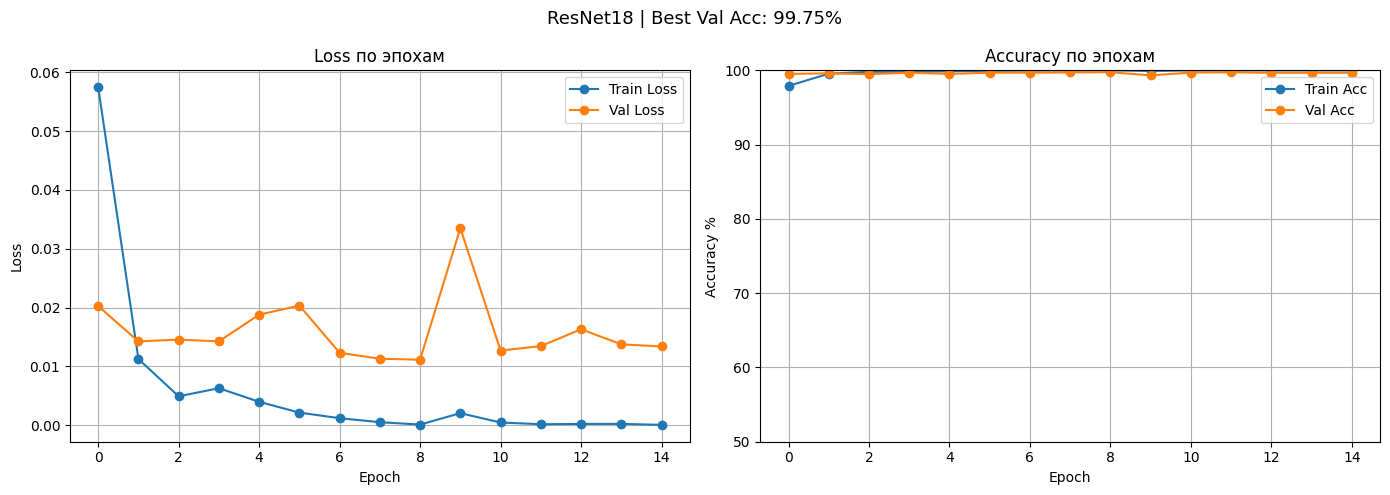

График сохранён: /content/training_history.png


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. НАСТРОЙКИ
# ============================================================
TILES_PATH   = '/content/tiles_balanced'
BATCH_SIZE   = 64
EPOCHS       = 15
LR           = 1e-4        # learning rate
VAL_SPLIT    = 0.2         # 20% на валидацию
SEED         = 42
NUM_CHANNELS = 6           # наши 6 каналов (B,G,R,RE,NIR,NDVI)
NUM_CLASSES  = 2           # wheat / non-wheat

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ============================================================
# 2. DATASET — читает .npy файлы и нормализует каналы
# ============================================================
class TileDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []   # список (путь, метка)

        for label_dir in ['0', '1']:
            label     = int(label_dir)
            label_path = os.path.join(root_dir, label_dir)
            for fname in os.listdir(label_path):
                if fname.endswith('.npy'):
                    self.samples.append(
                        (os.path.join(label_path, fname), label)
                    )

        np.random.shuffle(self.samples)
        print(f"Датасет загружен: {len(self.samples)} тайлов")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tile = np.load(path)   # (6, 64, 64) float32

        # --- Нормализация каналов ---
        # Каналы 0-4: мультиспектральные (0-65535) → делим на 65535
        # Канал 5:    NDVI (-1 до 1)               → (x + 1) / 2  → (0 до 1)
        tile_norm = np.zeros_like(tile, dtype=np.float32)
        tile_norm[:5] = tile[:5] / 65535.0
        tile_norm[5]  = (tile[5] + 1.0) / 2.0

        # Clip на случай выбросов
        tile_norm = np.clip(tile_norm, 0.0, 1.0)

        tensor = torch.from_numpy(tile_norm)   # (6, 64, 64)
        return tensor, label

# ============================================================
# 3. МОДЕЛЬ — ResNet18 адаптированная под 6 каналов
# ============================================================
def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Меняем первый слой: было 3 канала → стало 6
    old_conv   = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels  = num_channels,
        out_channels = old_conv.out_channels,
        kernel_size  = old_conv.kernel_size,
        stride       = old_conv.stride,
        padding      = old_conv.padding,
        bias         = False
    )

    # Умная инициализация: копируем RGB веса, остальные 3 канала — среднее
    with torch.no_grad():
        model.conv1.weight[:, :3, :, :] = old_conv.weight.clone()
        mean_w = old_conv.weight.mean(dim=1, keepdim=True)
        model.conv1.weight[:, 3:, :, :] = mean_w.repeat(1, num_channels-3, 1, 1)

    # Меняем последний слой: было 1000 классов ImageNet → стало 2
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

# ============================================================
# 4. ТРЕНИРОВОЧНЫЙ ЦИКЛ
# ============================================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if batch_idx % 50 == 0:
            print(f"    Батч {batch_idx}/{len(loader)} | "
                  f"loss={loss.item():.4f} | "
                  f"acc={100*correct/total:.1f}%", end='\r')

    return total_loss / len(loader), 100 * correct / total

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), 100 * correct / total

# ============================================================
# 5. ЗАПУСК
# ============================================================

# Датасет и сплит
full_dataset = TileDataset(TILES_PATH)
val_size     = int(len(full_dataset) * VAL_SPLIT)
train_size   = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {train_size} | Val: {val_size}")

# Модель
model     = build_model(NUM_CHANNELS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"\nМодель: ResNet18 (6 каналов → 2 класса)")
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

# История метрик
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc  = 0.0
best_model_path = '/content/best_model.pth'

print(f"\n{'='*55}")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>9} | {'Val Acc':>8} | {'':>6}")
print(f"{'='*55}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = val_epoch  (model, val_loader,   criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>9.4f} | {val_acc:>7.2f}% | "
          f"{'★ BEST' if is_best else ''}")

print(f"\nЛучшая val accuracy: {best_val_acc:.2f}%")
print(f"Модель сохранена: {best_model_path}")

# ============================================================
# 6. ГРАФИК ОБУЧЕНИЯ
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'],   label='Val Loss',   marker='o')
ax1.set_title('Loss по эпохам')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'],   label='Val Acc',   marker='o')
ax2.set_title('Accuracy по эпохам')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.set_ylim([50, 100])
ax2.legend()
ax2.grid(True)

plt.suptitle(f'ResNet18 | Best Val Acc: {best_val_acc:.2f}%', fontsize=13)
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=100)
plt.show()
print("График сохранён: /content/training_history.png")

Модель загружена ✓
Запускаю инференс: /content/dataset/Component2-Processed UAV Imagery/wheat/13/13_06-08.tif
Это займёт ~1-2 минуты...

=== РЕЗУЛЬТАТЫ ===
Размер карты:      89 x 23 тайлов
Валидных тайлов:   2002 из 2047
Тайлов пшеница:    1941 (97.0%)
Тайлов не-пшеница: 61 (3.0%)
Средний NDVI:      0.174


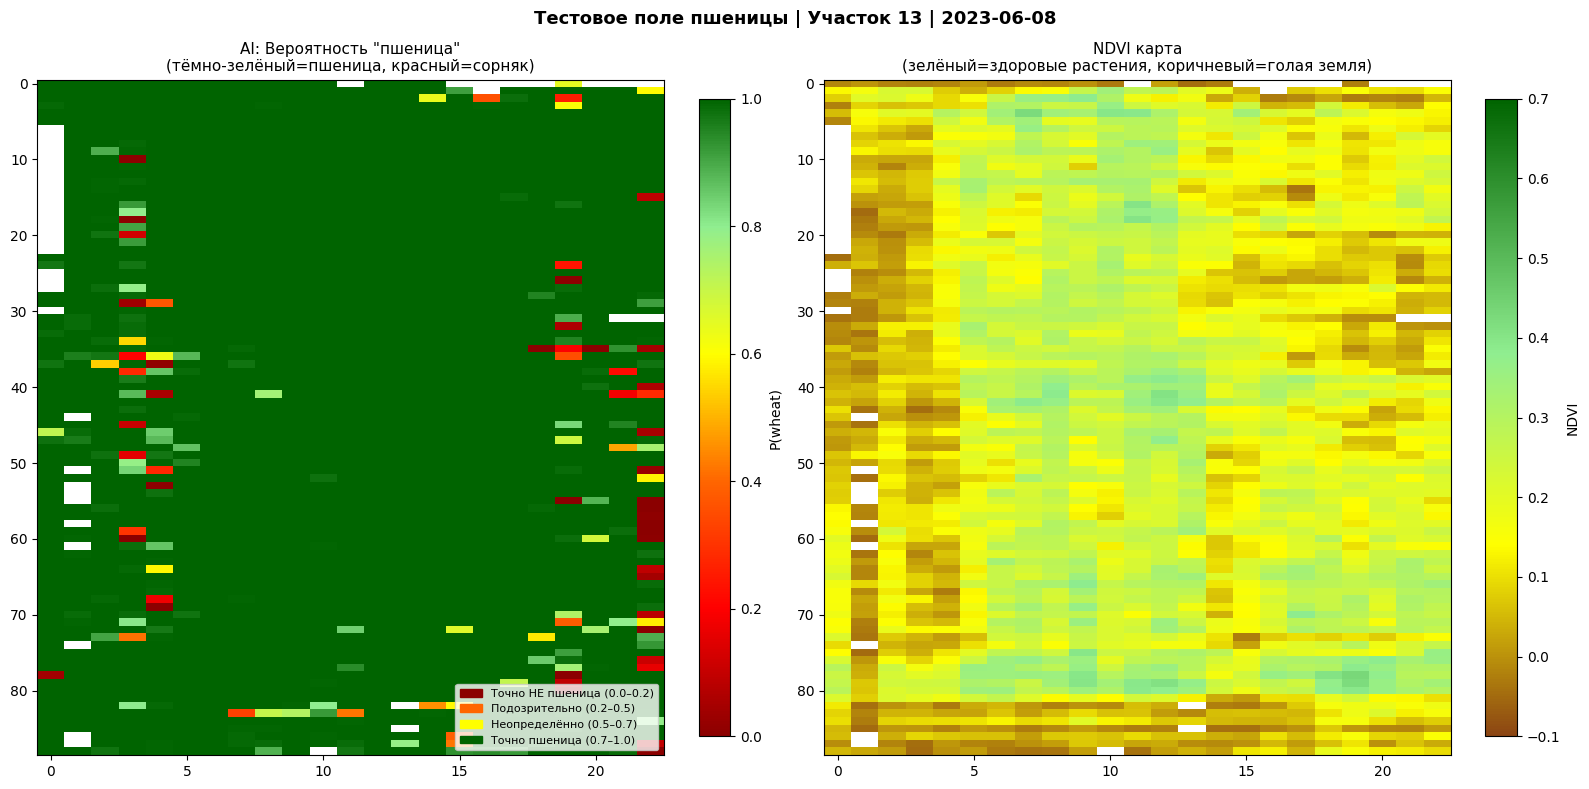


Карта сохранена: /content/field_map_wheat13.png


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ============================================================
# 1. ЗАГРУЖАЕМ ОБУЧЕННУЮ МОДЕЛЬ
# ============================================================
NUM_CHANNELS = 6
NUM_CLASSES  = 2
TILE_SIZE    = 64
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=None)
    old_conv    = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels  = num_channels,
        out_channels = old_conv.out_channels,
        kernel_size  = old_conv.kernel_size,
        stride       = old_conv.stride,
        padding      = old_conv.padding,
        bias         = False
    )
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model(NUM_CHANNELS, NUM_CLASSES)
model.load_state_dict(torch.load('/content/best_model.pth', map_location=device))
model = model.to(device)
model.eval()
print("Модель загружена ✓")

# ============================================================
# 2. ФУНКЦИЯ ИНФЕРЕНСА — прогоняем весь снимок по тайлам
# ============================================================
def run_inference(tiff_path, model, tile_size=64, batch_size=256):
    """
    Нарезает снимок на тайлы, прогоняет через модель батчами.
    Возвращает:
      prob_map  — карта вероятностей (0.0=точно не пшеница, 1.0=точно пшеница)
      ndvi_map  — средний NDVI каждого тайла
      valid_map — маска валидных тайлов
    """
    with rasterio.open(tiff_path) as src:
        data = src.read()   # (6, H, W)
    _, H, W = data.shape

    n_rows = H // tile_size
    n_cols = W // tile_size

    prob_map  = np.full((n_rows, n_cols), np.nan)
    ndvi_map  = np.full((n_rows, n_cols), np.nan)
    valid_map = np.zeros((n_rows, n_cols), dtype=bool)

    # Собираем батч тайлов
    batch_tensors = []
    batch_coords  = []

    def process_batch(batch_tensors, batch_coords):
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            outputs = model(batch)
            probs   = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        for (r, c), prob in zip(batch_coords, probs):
            prob_map[r, c]  = prob
            valid_map[r, c] = True

    for r in range(n_rows):
        for c in range(n_cols):
            y1 = r * tile_size;  y2 = y1 + tile_size
            x1 = c * tile_size;  x2 = x1 + tile_size
            tile = data[:, y1:y2, x1:x2]

            # Фильтр пустых тайлов
            red = tile[2]
            if np.sum(red == 0) / red.size > 0.3:
                continue
            ndvi_vals = tile[5][red > 0]
            if len(ndvi_vals) == 0 or ndvi_vals.mean() < -0.05:
                continue

            # Нормализация
            tile_norm      = np.zeros_like(tile, dtype=np.float32)
            tile_norm[:5]  = tile[:5] / 65535.0
            tile_norm[5]   = (tile[5] + 1.0) / 2.0
            tile_norm      = np.clip(tile_norm, 0.0, 1.0)

            # NDVI для карты
            ndvi_map[r, c] = ndvi_vals.mean()

            batch_tensors.append(torch.from_numpy(tile_norm))
            batch_coords.append((r, c))

            if len(batch_tensors) == batch_size:
                process_batch(batch_tensors, batch_coords)
                batch_tensors.clear()
                batch_coords.clear()

    if batch_tensors:
        process_batch(batch_tensors, batch_coords)

    return prob_map, ndvi_map, valid_map

# ============================================================
# 3. СТРОИМ ТЕПЛОВУЮ КАРТУ
# ============================================================
def plot_field_map(prob_map, ndvi_map, valid_map, title="Карта поля"):
    """
    Цветовая градация по вероятности принадлежности к пшенице:
    Тёмно-красный = точно НЕ пшеница (сорняк)
    Жёлтый        = под подозрением
    Тёмно-зелёный = точно пшеница
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # --- Левая карта: AI классификация ---
    # Цвета: 0.0=тёмно-красный, 0.5=жёлтый, 1.0=тёмно-зелёный
    cmap_ai = mcolors.LinearSegmentedColormap.from_list(
        'field_health',
        [(0.0, '#8B0000'),   # тёмно-красный  (бордовый)
         (0.2, '#FF0000'),   # красный
         (0.4, '#FF6600'),   # оранжевый
         (0.6, '#FFFF00'),   # жёлтый
         (0.8, '#90EE90'),   # светло-зелёный
         (1.0, '#006400')]   # тёмно-зелёный
    )

    display_ai = np.where(valid_map, prob_map, np.nan)
    im1 = axes[0].imshow(display_ai, cmap=cmap_ai, vmin=0, vmax=1,
                         interpolation='nearest', aspect='auto')
    axes[0].set_title('AI: Вероятность "пшеница"\n(тёмно-зелёный=пшеница, красный=сорняк)',
                      fontsize=11)
    plt.colorbar(im1, ax=axes[0], fraction=0.046,
                 label='P(wheat)')

    # Добавляем легенду
    legend_elements = [
        Patch(color='#8B0000', label='Точно НЕ пшеница (0.0–0.2)'),
        Patch(color='#FF6600', label='Подозрительно (0.2–0.5)'),
        Patch(color='#FFFF00', label='Неопределённо (0.5–0.7)'),
        Patch(color='#006400', label='Точно пшеница (0.7–1.0)'),
    ]
    axes[0].legend(handles=legend_elements, loc='lower right',
                   fontsize=8, framealpha=0.8)

    # --- Правая карта: NDVI ---
    cmap_ndvi = mcolors.LinearSegmentedColormap.from_list(
        'ndvi',
        [(0.0, '#8B4513'),   # коричневый (нет растений)
         (0.3, '#FFFF00'),   # жёлтый     (слабый рост)
         (0.6, '#90EE90'),   # светло-зел
         (1.0, '#006400')]   # тёмно-зел  (густой здоровый)
    )
    display_ndvi = np.where(valid_map, ndvi_map, np.nan)
    im2 = axes[1].imshow(display_ndvi, cmap=cmap_ndvi,
                         vmin=-0.1, vmax=0.7,
                         interpolation='nearest', aspect='auto')
    axes[1].set_title('NDVI карта\n(зелёный=здоровые растения, коричневый=голая земля)',
                      fontsize=11)
    plt.colorbar(im2, ax=axes[1], fraction=0.046, label='NDVI')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

# ============================================================
# 4. ЗАПУСКАЕМ НА ТЕСТОВОМ СНИМКЕ
#    Берём снимок которого модель НЕ видела при обучении
#    (участок 13, дата 06-08 — не попал в выборку)
# ============================================================
test_tiff = '/content/dataset/Component2-Processed UAV Imagery/wheat/13/13_06-08.tif'

print(f"Запускаю инференс: {test_tiff}")
print("Это займёт ~1-2 минуты...")

prob_map, ndvi_map, valid_map = run_inference(test_tiff, model)

valid_tiles = valid_map.sum()
total_tiles = valid_map.size
wheat_tiles = (prob_map[valid_map] > 0.5).sum()

print(f"\n=== РЕЗУЛЬТАТЫ ===")
print(f"Размер карты:      {prob_map.shape[0]} x {prob_map.shape[1]} тайлов")
print(f"Валидных тайлов:   {valid_tiles} из {total_tiles}")
print(f"Тайлов пшеница:    {wheat_tiles} ({100*wheat_tiles/valid_tiles:.1f}%)")
print(f"Тайлов не-пшеница: {valid_tiles-wheat_tiles} ({100*(valid_tiles-wheat_tiles)/valid_tiles:.1f}%)")
print(f"Средний NDVI:      {np.nanmean(ndvi_map):.3f}")

fig = plot_field_map(prob_map, ndvi_map, valid_map,
                     title=f"Тестовое поле пшеницы | Участок 13 | 2023-06-08")
plt.savefig('/content/field_map_wheat13.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nКарта сохранена: /content/field_map_wheat13.png")

Модель загружена ✓
Загружаю тайлы пшеницы...
  Пшеница: 3000 тайлов ✓
Загружаю тайлы сои...
  Соя:     3000 тайлов ✓

Синтетическое поле: 60x80 тайлов
Тайлов с соей:    202 (4.2%)
Тайлов пшеницы:   4598

Запускаю инференс...
Инференс завершён ✓

=== ТОЧНОСТЬ ДЕТЕКЦИИ ===
Реально заражённых тайлов:   158
Правильно обнаружено:        158 (100.0%)
Пропущено:                   0
Средняя ошибка карты:        0.0218


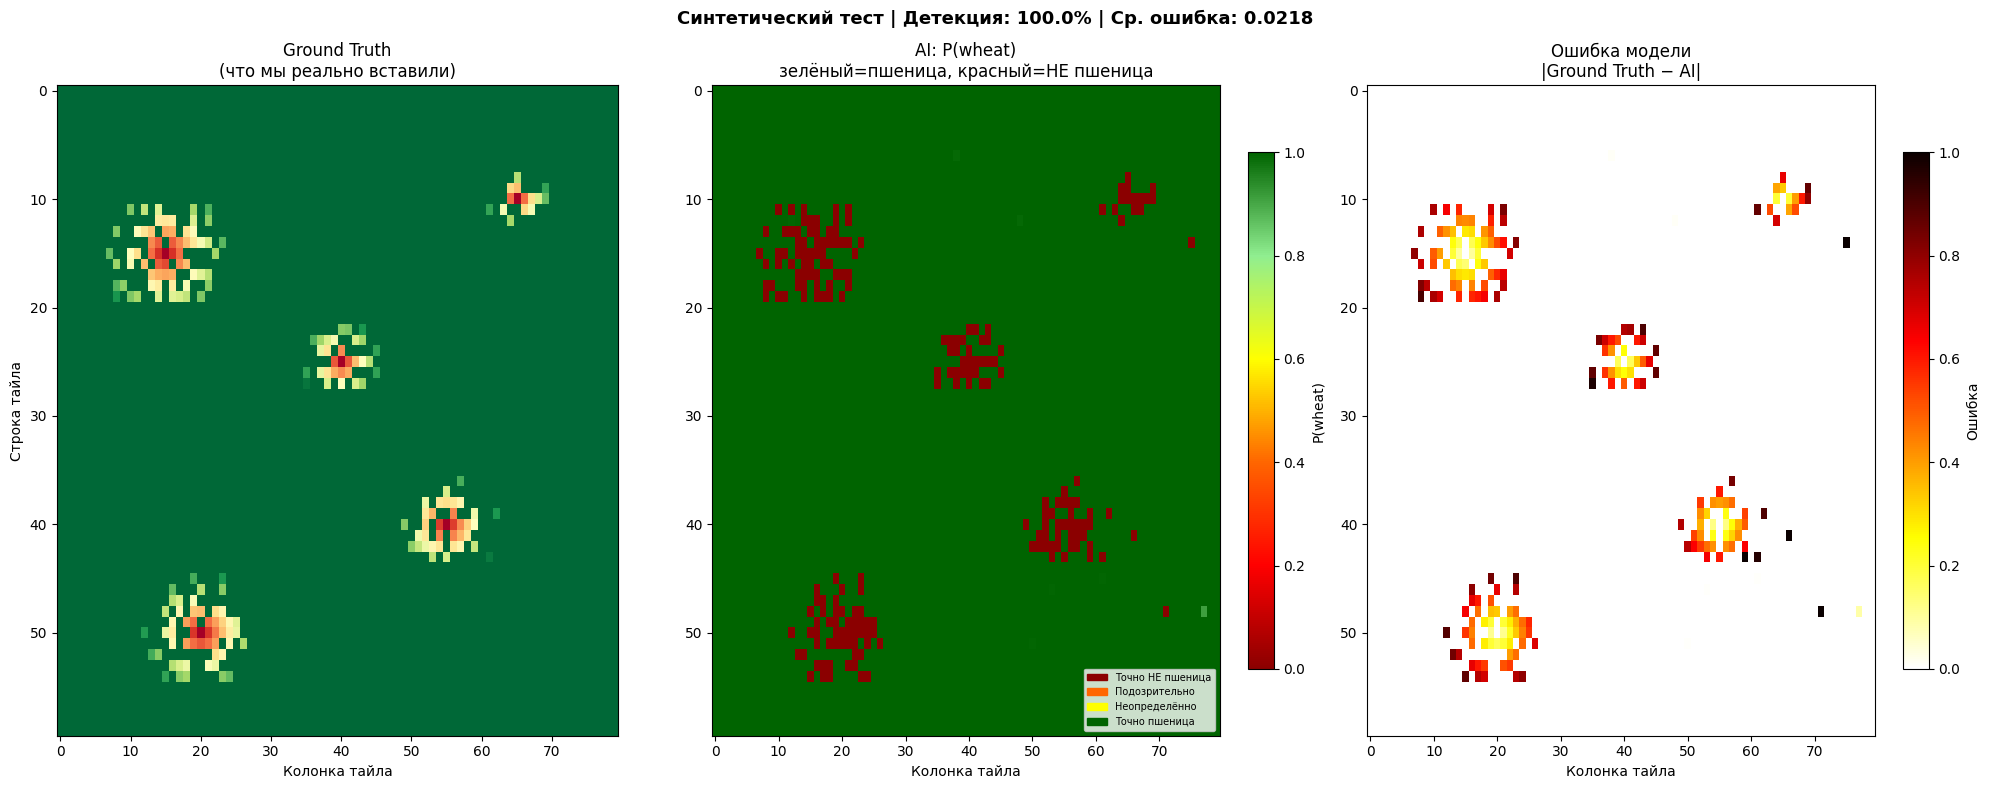


Карта сохранена: /content/synthetic_test.png


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ============================================================
# 1. ЗАГРУЖАЕМ МОДЕЛЬ (если ещё не загружена)
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=None)
    old_conv    = model.conv1
    model.conv1 = nn.Conv2d(num_channels, old_conv.out_channels,
                            old_conv.kernel_size, old_conv.stride,
                            old_conv.padding, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model()
model.load_state_dict(torch.load('/content/best_model.pth', map_location=device))
model = model.to(device)
model.eval()
print("Модель загружена ✓")

# ============================================================
# 2. СОБИРАЕМ ПУЛЫ ТАЙЛОВ
# ============================================================
TILES_PATH = '/content/tiles_balanced'
N_LOAD     = 3000   # сколько тайлов загружаем в память

def load_tiles(label_dir, n=N_LOAD):
    path  = os.path.join(TILES_PATH, label_dir)
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    np.random.shuffle(files)
    tiles = []
    for fname in files[:n]:
        t = np.load(os.path.join(path, fname))
        tiles.append(t)
    return tiles

print("Загружаю тайлы пшеницы...")
wheat_tiles   = load_tiles('1', N_LOAD)
print(f"  Пшеница: {len(wheat_tiles)} тайлов ✓")

print("Загружаю тайлы сои...")
soy_tiles     = load_tiles('0', N_LOAD)
print(f"  Соя:     {len(soy_tiles)} тайлов ✓")

# ============================================================
# 3. СТРОИМ СИНТЕТИЧЕСКОЕ ПОЛЕ
# ============================================================
GRID_ROWS = 60    # размер поля в тайлах
GRID_COLS = 80

np.random.seed(42)

# Заполняем всё пшеницей
field = np.random.choice(len(wheat_tiles), size=(GRID_ROWS, GRID_COLS))
source_map = np.zeros((GRID_ROWS, GRID_COLS), dtype=int)  # 0=wheat, 1=soy

# ── Создаём очаги заражения (эллиптические пятна) ──────────
outbreaks = [
    # (центр_строка, центр_колонка, радиус_строки, радиус_колонки, интенсивность)
    # интенсивность: 1.0 = 100% соя в центре, к краям — градация
    (15, 15, 7,  10, 1.0),   # большой очаг слева
    (40, 55, 5,  8,  1.0),   # очаг справа
    (25, 40, 4,  6,  1.0),   # маленький очаг по центру
    (50, 20, 6,  9,  1.0),   # очаг снизу слева
    (10, 65, 3,  5,  1.0),   # маленький очаг справа вверху
]

# Для каждого пикселя считаем "заражённость" — расстояние до ближайшего центра
infection_map = np.zeros((GRID_ROWS, GRID_COLS))  # 0=чисто, 1=заражено

for (cr, cc, rr, rc, intensity) in outbreaks:
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            # Нормализованное эллиптическое расстояние
            dist = np.sqrt(((r - cr) / rr) ** 2 + ((c - cc) / rc) ** 2)
            if dist <= 1.0:
                # В центре = intensity, на краю = 0, плавный градиент
                local_infection = intensity * (1.0 - dist)
                infection_map[r, c] = max(infection_map[r, c], local_infection)

# Заполняем тайлами сои согласно карте заражения
soy_indices   = np.random.choice(len(soy_tiles),   size=(GRID_ROWS, GRID_COLS))
wheat_indices = np.random.choice(len(wheat_tiles), size=(GRID_ROWS, GRID_COLS))

tile_grid = []   # финальная сетка тайлов
true_infection = np.zeros((GRID_ROWS, GRID_COLS))  # ground truth

for r in range(GRID_ROWS):
    row_tiles = []
    for c in range(GRID_COLS):
        inf = infection_map[r, c]
        # Вероятностный выбор: чем выше заражённость, тем скорее соя
        if np.random.random() < inf:
            row_tiles.append(soy_tiles[soy_indices[r, c]])
            true_infection[r, c] = inf
        else:
            row_tiles.append(wheat_tiles[wheat_indices[r, c]])
    tile_grid.append(row_tiles)

soy_count = (true_infection > 0).sum()
print(f"\nСинтетическое поле: {GRID_ROWS}x{GRID_COLS} тайлов")
print(f"Тайлов с соей:    {soy_count} ({100*soy_count/(GRID_ROWS*GRID_COLS):.1f}%)")
print(f"Тайлов пшеницы:   {GRID_ROWS*GRID_COLS - soy_count}")

# ============================================================
# 4. ИНФЕРЕНС НА СИНТЕТИЧЕСКОМ ПОЛЕ
# ============================================================
def normalize_tile(tile):
    t = np.zeros_like(tile, dtype=np.float32)
    t[:5] = tile[:5] / 65535.0
    t[5]  = (tile[5] + 1.0) / 2.0
    return np.clip(t, 0.0, 1.0)

print("\nЗапускаю инференс...")
prob_map = np.zeros((GRID_ROWS, GRID_COLS))

BATCH_SIZE = 256
batch_tensors = []
batch_coords  = []

def flush_batch(batch_tensors, batch_coords, prob_map):
    batch = torch.stack(batch_tensors).to(device)
    with torch.no_grad():
        out   = model(batch)
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    for (r, c), p in zip(batch_coords, probs):
        prob_map[r, c] = p

for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        tile = tile_grid[r][c]
        batch_tensors.append(torch.from_numpy(normalize_tile(tile)))
        batch_coords.append((r, c))
        if len(batch_tensors) == BATCH_SIZE:
            flush_batch(batch_tensors, batch_coords, prob_map)
            batch_tensors.clear()
            batch_coords.clear()

if batch_tensors:
    flush_batch(batch_tensors, batch_coords, prob_map)

print("Инференс завершён ✓")

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ — три карты рядом
# ============================================================
cmap_ai = mcolors.LinearSegmentedColormap.from_list(
    'field_health',
    [(0.0, '#8B0000'),
     (0.2, '#FF0000'),
     (0.4, '#FF6600'),
     (0.6, '#FFFF00'),
     (0.8, '#90EE90'),
     (1.0, '#006400')]
)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# --- Карта 1: Ground Truth (что мы вставили) ---
axes[0].imshow(true_infection, cmap='RdYlGn_r', vmin=0, vmax=1,
               interpolation='nearest', aspect='auto')
axes[0].set_title('Ground Truth\n(что мы реально вставили)', fontsize=12)
axes[0].set_xlabel('Колонка тайла')
axes[0].set_ylabel('Строка тайла')

# --- Карта 2: AI предсказание ---
# Инвертируем: prob=1 (пшеница)=зелёный, prob=0 (соя)=красный
im2 = axes[1].imshow(prob_map, cmap=cmap_ai, vmin=0, vmax=1,
                     interpolation='nearest', aspect='auto')
axes[1].set_title('AI: P(wheat)\nзелёный=пшеница, красный=НЕ пшеница', fontsize=12)
axes[1].set_xlabel('Колонка тайла')
plt.colorbar(im2, ax=axes[1], fraction=0.046, label='P(wheat)')

# --- Карта 3: Разница (ошибки модели) ---
# Считаем "тревогу": 1 - P(wheat) = P(не пшеница)
threat_map = 1.0 - prob_map
diff = np.abs(true_infection - threat_map)
im3 = axes[2].imshow(diff, cmap='hot_r', vmin=0, vmax=1,
                     interpolation='nearest', aspect='auto')
axes[2].set_title('Ошибка модели\n|Ground Truth − AI|', fontsize=12)
axes[2].set_xlabel('Колонка тайла')
plt.colorbar(im3, ax=axes[2], fraction=0.046, label='Ошибка')

# Легенда
legend_elements = [
    Patch(color='#8B0000', label='Точно НЕ пшеница'),
    Patch(color='#FF6600', label='Подозрительно'),
    Patch(color='#FFFF00', label='Неопределённо'),
    Patch(color='#006400', label='Точно пшеница'),
]
axes[1].legend(handles=legend_elements, loc='lower right',
               fontsize=7, framealpha=0.8)

# Статистика
detected = (prob_map[true_infection > 0.3] < 0.5).sum()
total_infected = (true_infection > 0.3).sum()
print(f"\n=== ТОЧНОСТЬ ДЕТЕКЦИИ ===")
print(f"Реально заражённых тайлов:   {total_infected}")
print(f"Правильно обнаружено:        {detected} ({100*detected/total_infected:.1f}%)")
print(f"Пропущено:                   {total_infected - detected}")
mean_err = diff.mean()
print(f"Средняя ошибка карты:        {mean_err:.4f}")

plt.suptitle(f'Синтетический тест | Детекция: {100*detected/total_infected:.1f}% | '
             f'Ср. ошибка: {mean_err:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/synthetic_test.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nКарта сохранена: /content/synthetic_test.png")

In [ ]:
from google.colab import drive
import shutil, os, torch, json
from datetime import datetime

# Подключаем Google Drive
drive.mount('/content/drive')

# Создаём папку проекта на Drive
save_dir = '/content/drive/MyDrive/DroneAI_WheatClassifier'
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. Сохраняем модель
# ============================================================
shutil.copy2('/content/best_model.pth', f'{save_dir}/best_model.pth')
print(f"✓ Модель сохранена")

# ============================================================
# 2. Сохраняем метаданные — чтобы потом знать как модель обучалась
# ============================================================
metadata = {
    "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "architecture": "ResNet18",
    "input_channels": 6,
    "channel_order": ["Blue", "Green", "Red", "RedEdge", "NIR", "NDVI"],
    "num_classes": 2,
    "classes": {"0": "non-wheat (soybean)", "1": "wheat"},
    "tile_size_px": 64,
    "tile_size_meters": "~2x2m (GSD=3cm)",
    "normalization": {
        "channels_0_4": "divide by 65535",
        "channel_5_ndvi": "(x + 1) / 2"
    },
    "training": {
        "dataset": "MDPI Multispectral UAV Kazakhstan",
        "train_samples": 24000,
        "val_samples": 6000,
        "epochs": 15,
        "batch_size": 64,
        "learning_rate": 0.0001,
        "best_val_accuracy": 99.75,
        "best_epoch": 9
    },
    "inference": {
        "empty_threshold": 0.3,
        "min_ndvi": -0.05,
        "wheat_threshold": 0.5
    }
}

with open(f'{save_dir}/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✓ Метаданные сохранены")

# ============================================================
# 3. Проверяем что всё сохранилось
# ============================================================
print(f"\n=== Содержимое папки на Google Drive ===")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    size  = os.path.getsize(fpath) / 1024**2
    print(f"  {fname:35s} {size:.1f} МБ")

print(f"\nПапка на Drive: DroneAI_WheatClassifier/")
print(f"Всё сохранено. Прогресс в безопасности ✓")

Mounted at /content/drive
✓ Модель сохранена
✓ Метаданные сохранены

=== Содержимое папки на Google Drive ===
  best_model.pth                      42.8 МБ
  model_metadata.json                 0.0 МБ

Папка на Drive: DroneAI_WheatClassifier/
Всё сохранено. Прогресс в безопасности ✓


In [ ]:
# ============================================================
# ВОССТАНОВЛЕНИЕ СЕССИИ — запустите эту ячейку первой
# ============================================================
import os, numpy as np, torch, torch.nn as nn
from torchvision import models
from google.colab import drive

# 1. Подключаем Google Drive
drive.mount('/content/drive')

# 2. Загружаем модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=None)
    old_conv    = model.conv1
    model.conv1 = nn.Conv2d(num_channels, old_conv.out_channels,
                            old_conv.kernel_size, old_conv.stride,
                            old_conv.padding, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model()
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/DroneAI_WheatClassifier/best_model.pth',
    map_location=device
))
model = model.to(device)
model.eval()
print("Модель загружена с Google Drive ✓")

# 3. Проверяем есть ли тайлы
tiles_ok = (
    os.path.exists('/content/tiles_balanced/0') and
    len(os.listdir('/content/tiles_balanced/0')) > 100
)
print(f"Тайлы на месте: {'✓' if tiles_ok else '✗ — нужно пересоздать'}")

Mounted at /content/drive
Устройство: cuda
Модель загружена с Google Drive ✓
Тайлы на месте: ✗ — нужно пересоздать


In [ ]:
import os, numpy as np, rasterio
from pathlib import Path

# Проверяем датасет
dataset_ok = os.path.exists('/content/dataset/Component2-Processed UAV Imagery/wheat')
zip_ok     = os.path.exists('/content/Component2.zip')

print(f"Датасет распакован: {'✓' if dataset_ok else '✗'}")
print(f"ZIP архив есть:     {'✓' if zip_ok else '✗'}")

if not dataset_ok and zip_ok:
    print("\nРаспаковываю архив...")
    os.makedirs('/content/dataset', exist_ok=True)
    os.system('unzip -q /content/Component2.zip -d /content/dataset')
    print("Распаковка завершена ✓")
elif not dataset_ok and not zip_ok:
    print("\n✗ Нет ни датасета ни ZIP — нужно скачать заново")
    print("Скачиваю с Zenodo...")
    os.makedirs('/content/dataset', exist_ok=True)
    os.system('wget -q --show-progress -O /content/Component2.zip '
              '"https://zenodo.org/records/7860751/files/Component2-Processed%20UAV%20Imagery.zip?download=1"')
    os.system('unzip -q /content/Component2.zip -d /content/dataset')
    print("Скачивание и распаковка завершены ✓")

# Нарезаем тайлы сразу с лимитом
TILE_SIZE     = 64
EMPTY_THRESH  = 0.3
MIN_NDVI      = -0.05
MAX_PER_CLASS = 15000
BASE_PATH     = '/content/dataset/Component2-Processed UAV Imagery'
OUTPUT_PATH   = '/content/tiles_balanced'

CLASSES = {
    'wheat':   {'path': os.path.join(BASE_PATH, 'wheat'),   'label': 1},
    'soybean': {'path': os.path.join(BASE_PATH, 'soybean'), 'label': 0},
}

import shutil
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(f'{OUTPUT_PATH}/0', exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/1', exist_ok=True)

def col_to_letter(col_idx):
    result = ''
    col_idx += 1
    while col_idx > 0:
        col_idx, remainder = divmod(col_idx - 1, 26)
        result = chr(65 + remainder) + result
    return result

def is_valid_tile(tile):
    red = tile[2]
    if np.sum(red == 0) / red.size > EMPTY_THRESH: return False
    valid_ndvi = tile[5][red > 0]
    if len(valid_ndvi) == 0 or valid_ndvi.mean() < MIN_NDVI: return False
    if np.sum(red >= 65530) / red.size > 0.5: return False
    return True

np.random.seed(42)

for crop_name, info in CLASSES.items():
    crop_path = info['path']
    label     = info['label']
    out_dir   = os.path.join(OUTPUT_PATH, str(label))
    saved     = 0

    print(f"\n{'='*45}")
    print(f"{crop_name.upper()} | Цель: {MAX_PER_CLASS} тайлов")
    print(f"{'='*45}")

    all_tiffs = []
    for plot_id in sorted(os.listdir(crop_path)):
        plot_full = os.path.join(crop_path, plot_id)
        if not os.path.isdir(plot_full): continue
        for f in sorted(os.listdir(plot_full)):
            if f.endswith('.tif'):
                all_tiffs.append((plot_id, os.path.join(plot_full, f), f))

    np.random.shuffle(all_tiffs)

    for plot_id, tiff_path, tiff_file in all_tiffs:
        if saved >= MAX_PER_CLASS: break

        flight_date = tiff_file.replace('.tif','').split('_')[-1]
        with rasterio.open(tiff_path) as src:
            data = src.read()
        _, H, W = data.shape

        indices = [(r, c) for r in range(H // TILE_SIZE)
                           for c in range(W // TILE_SIZE)]
        np.random.shuffle(indices)

        file_saved = 0
        for row_idx, col_idx in indices:
            if saved >= MAX_PER_CLASS: break
            y1,y2 = row_idx*TILE_SIZE, (row_idx+1)*TILE_SIZE
            x1,x2 = col_idx*TILE_SIZE, (col_idx+1)*TILE_SIZE
            tile = data[:, y1:y2, x1:x2]
            if not is_valid_tile(tile): continue
            fname = f"{label}_{crop_name}_{plot_id}_{flight_date}_{col_to_letter(col_idx)}{row_idx+1}.npy"
            np.save(os.path.join(out_dir, fname), tile.astype(np.float32))
            saved += 1; file_saved += 1

        print(f"  {plot_id}/{tiff_file}: +{file_saved} (всего {saved}/{MAX_PER_CLASS})")

    print(f"Итого {crop_name}: {saved} тайлов ✓")

print(f"\n{'='*45}")
for ld in ['0','1']:
    count = len([f for f in os.listdir(f'{OUTPUT_PATH}/{ld}') if f.endswith('.npy')])
    name  = 'wheat' if ld=='1' else 'non-wheat'
    print(f"Класс {ld} ({name}): {count} тайлов")
print("Готово — можно запускать тесты ✓")

Датасет распакован: ✗
ZIP архив есть:     ✗

✗ Нет ни датасета ни ZIP — нужно скачать заново
Скачиваю с Zenodo...
Скачивание и распаковка завершены ✓

WHEAT | Цель: 15000 тайлов
  10/10_05-18.tif: +314 (всего 314/15000)
  11/11_05-18.tif: +21 (всего 335/15000)
  23/23_06-08.tif: +2744 (всего 3079/15000)
  25/25_05-18.tif: +2898 (всего 5977/15000)
  12/12_07-12.tif: +2313 (всего 8290/15000)
  26/26_07-25.tif: +2761 (всего 11051/15000)
  22/22_07-12.tif: +2541 (всего 13592/15000)
  25/25_07-12.tif: +1408 (всего 15000/15000)
Итого wheat: 15000 тайлов ✓

SOYBEAN | Цель: 15000 тайлов
  19/19_06-21.tif: +2633 (всего 2633/15000)
  21/20_06-21.tif: +2326 (всего 4959/15000)
  21/20_07-25.tif: +2298 (всего 7257/15000)
  20/20_07-25.tif: +2836 (всего 10093/15000)
  21/20_06-08.tif: +973 (всего 11066/15000)
  21/20_07-12.tif: +2286 (всего 13352/15000)
  20/20_06-08.tif: +663 (всего 14015/15000)
  20/20_06-21.tif: +985 (всего 15000/15000)
Итого soybean: 15000 тайлов ✓

Класс 0 (non-wheat): 15000 та

Модель загружена ✓
Пшеница: 3000 | Соя: 3000 ✓

[1/6] Одиночный крупный очаг...


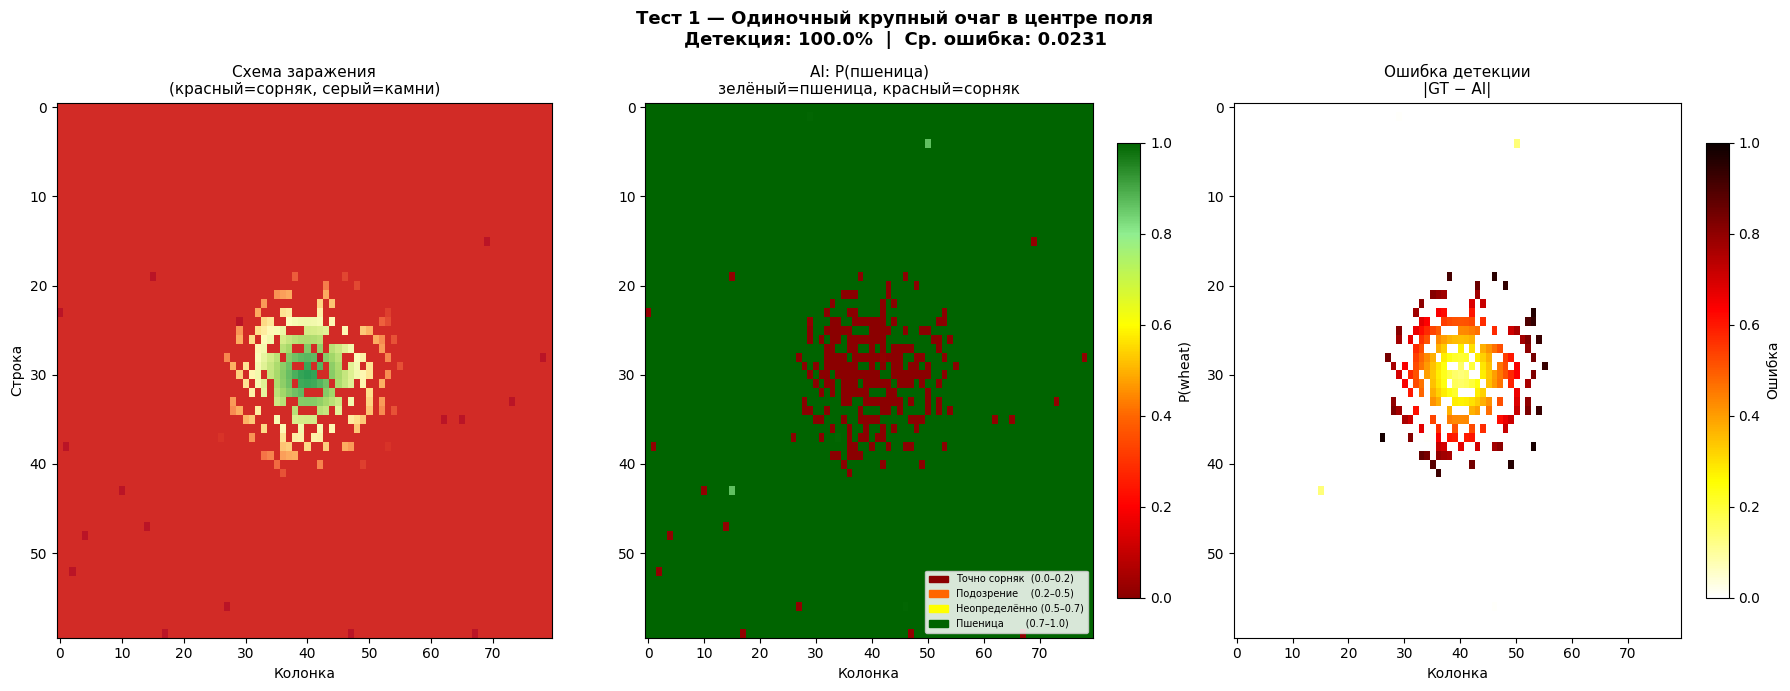

  Детекция: 100.0% | Ошибка: 0.0231 | test1.png

[2/6] Множество мелких очагов...


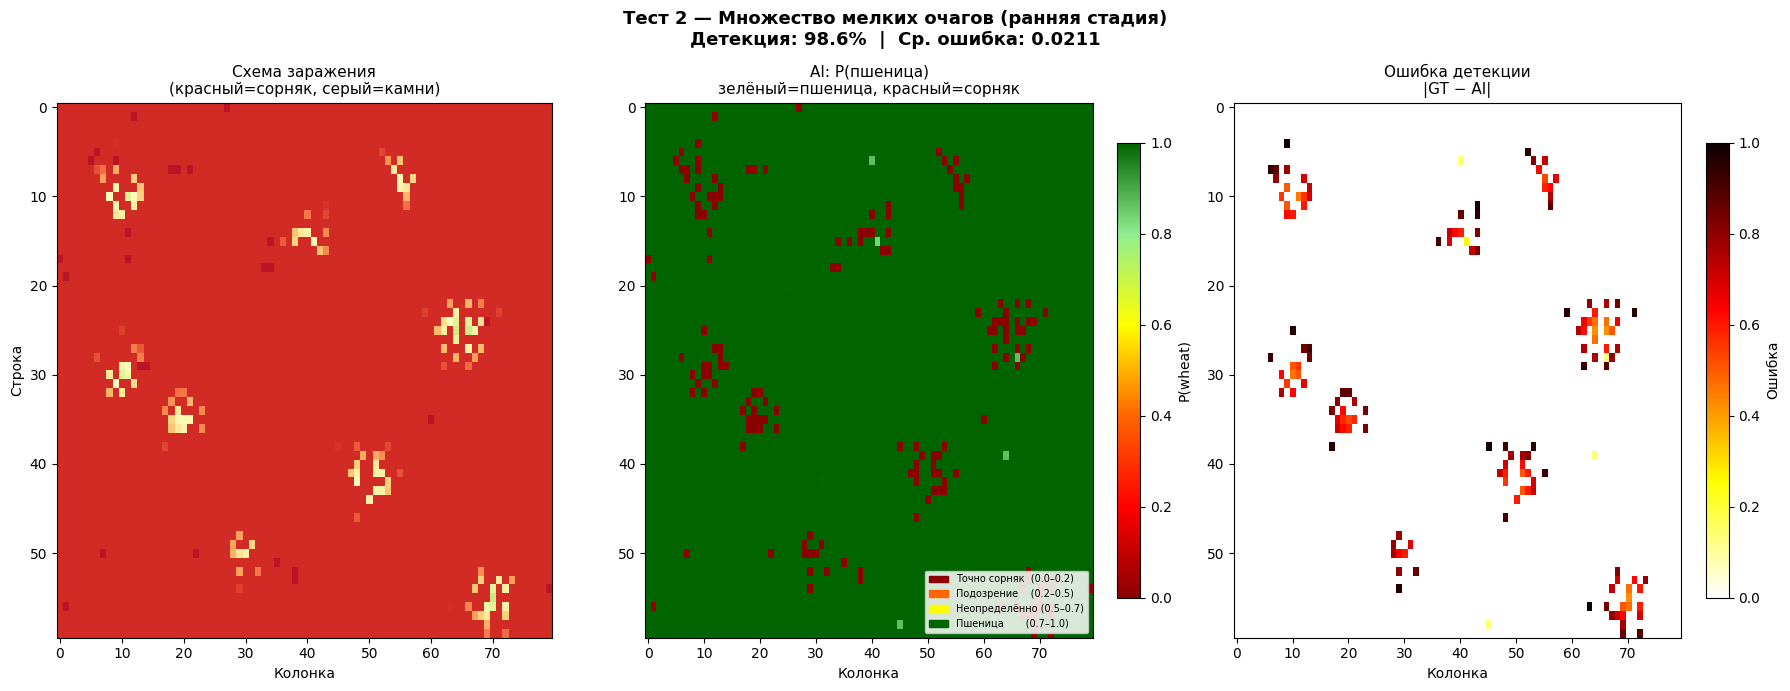

  Детекция: 98.6% | Ошибка: 0.0211 | test2.png

[3/6] Полосы заражения...


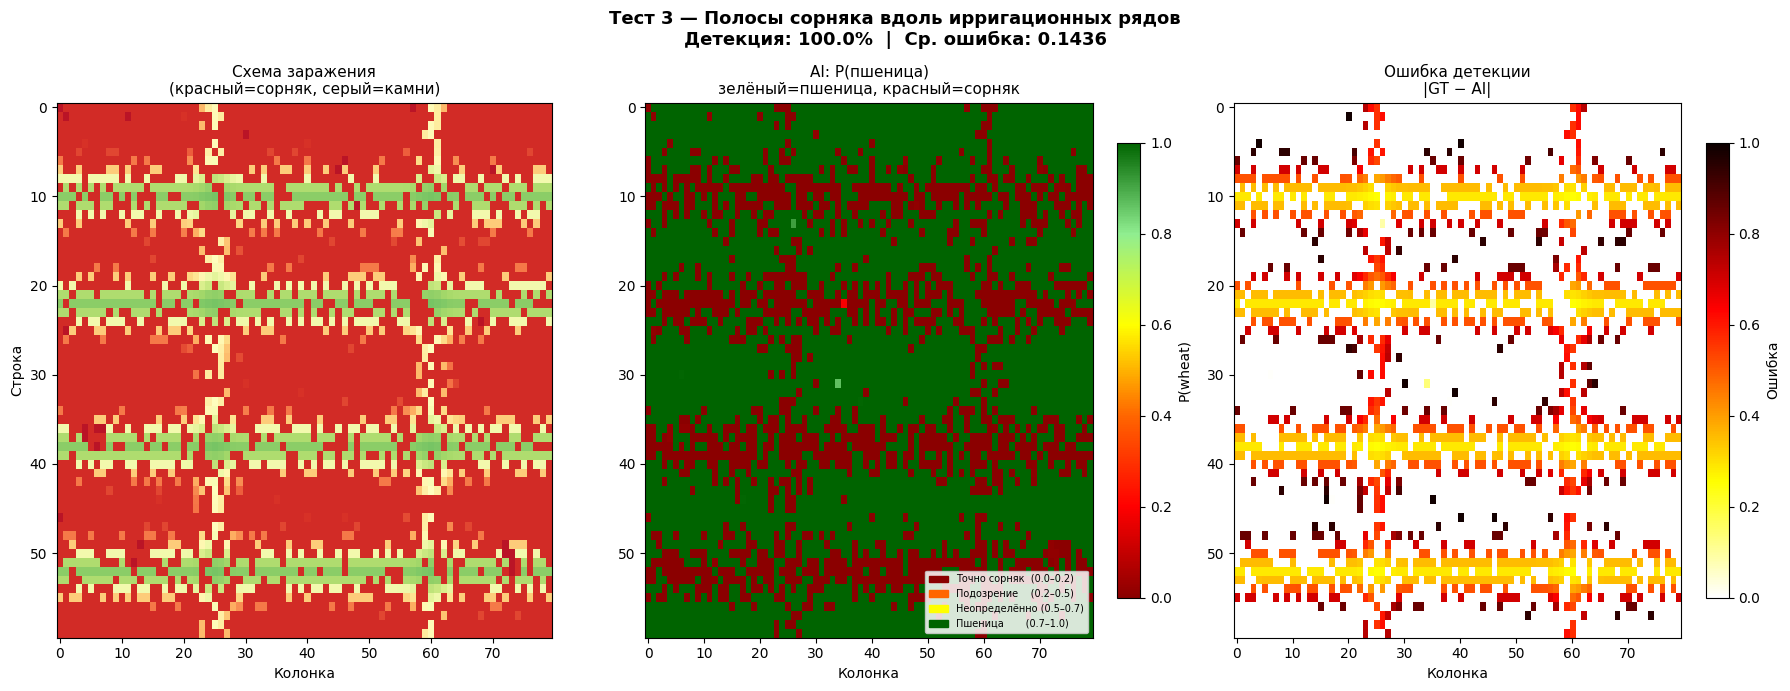

  Детекция: 100.0% | Ошибка: 0.1436 | test3.png

[4/6] Краевое заражение...


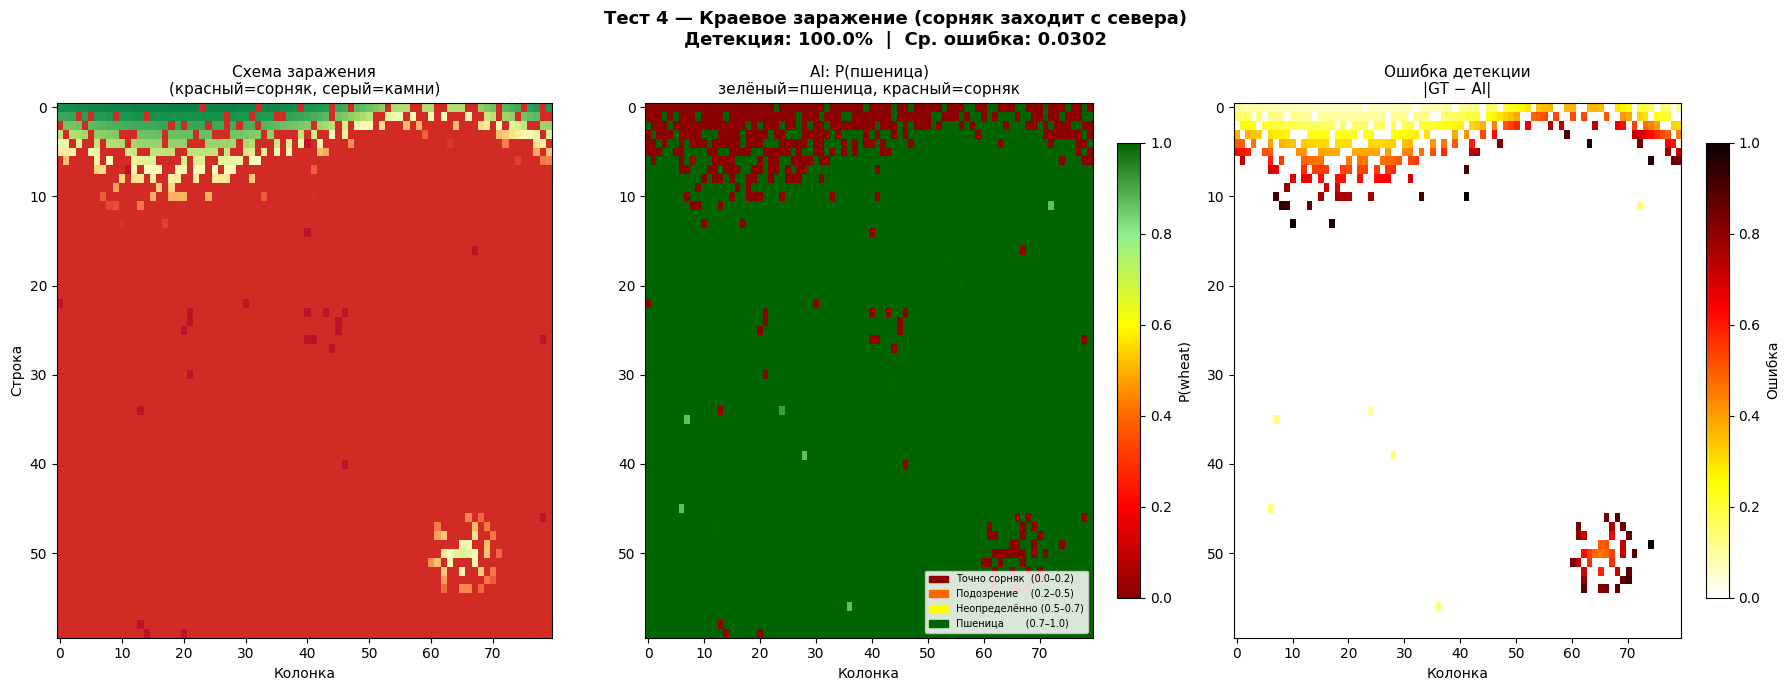

  Детекция: 100.0% | Ошибка: 0.0302 | test4.png

[5/6] Ветровое распространение...


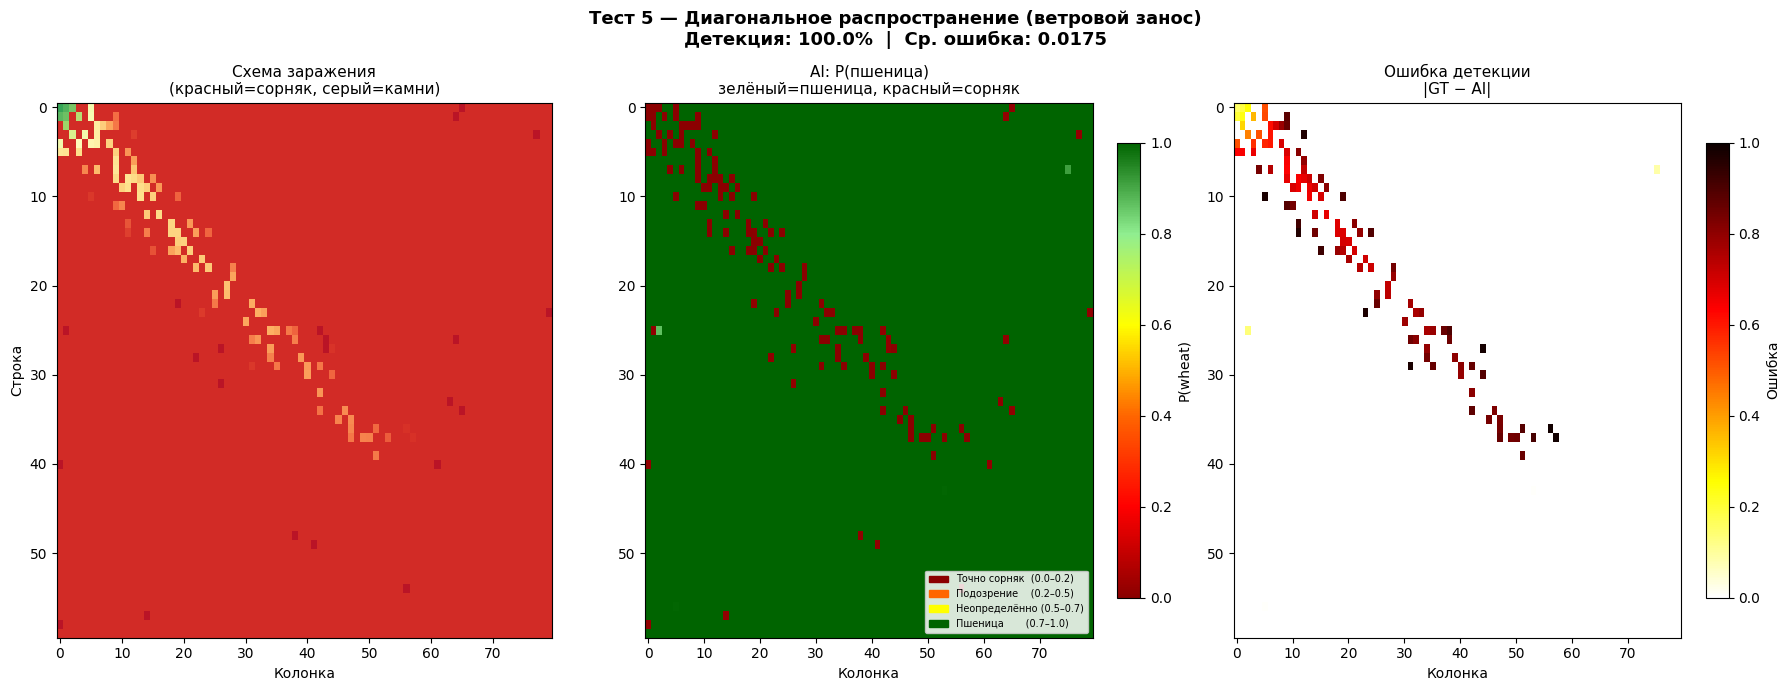

  Детекция: 100.0% | Ошибка: 0.0175 | test5.png

[6/6] Хаотичное заражение...


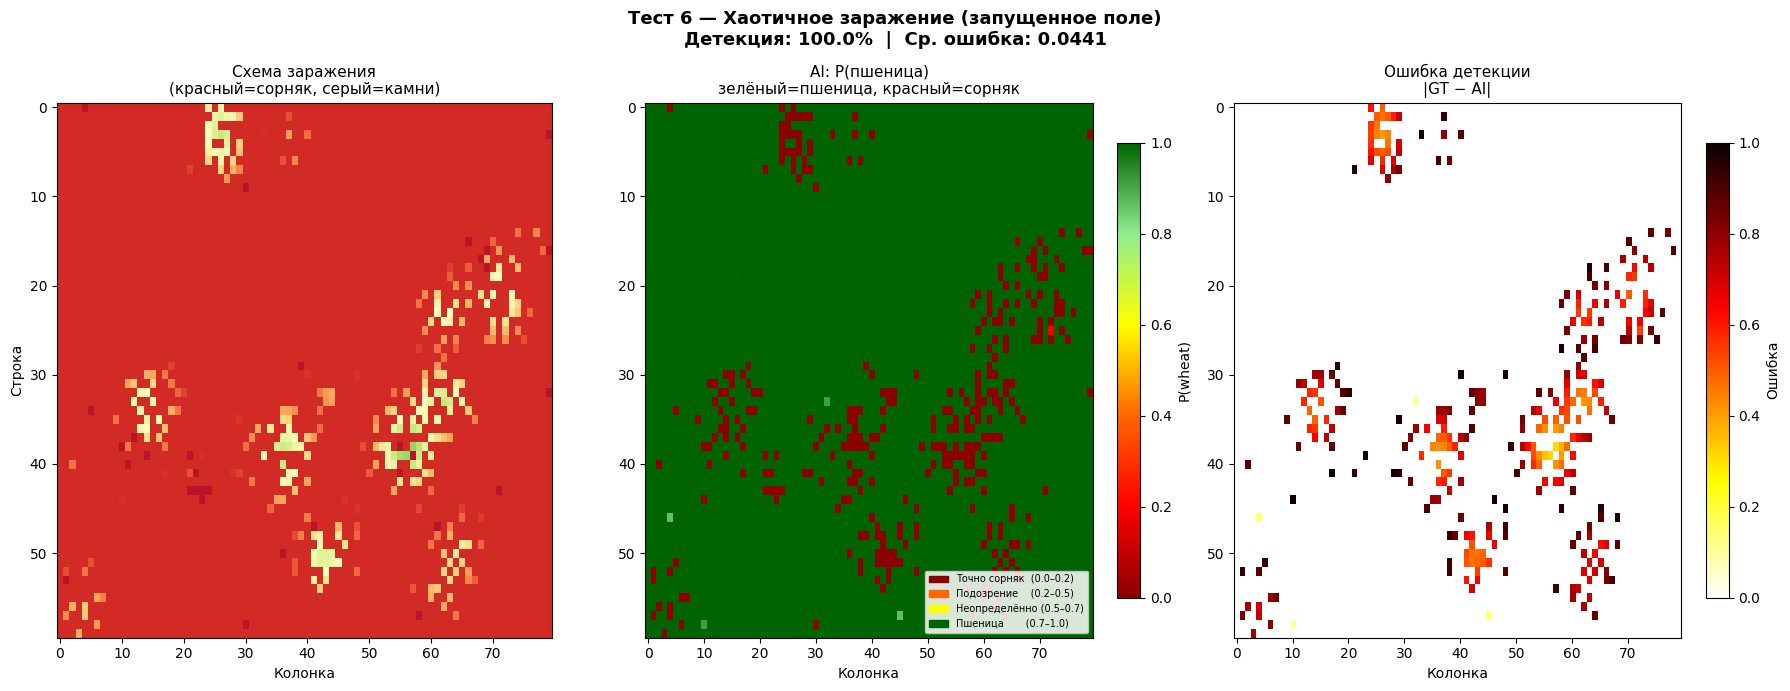

  Детекция: 100.0% | Ошибка: 0.0441 | test6.png

Сценарий                             Детекция  Ср.ошибка
Тест 1: Крупный очаг в центре          100.0%      0.0231
Тест 2: Мелкие очаги (ранняя стадия)     98.6%      0.0211
Тест 3: Полосы вдоль рядов             100.0%      0.1436
Тест 4: Краевое заражение              100.0%      0.0302
Тест 5: Ветровой занос                 100.0%      0.0175
Тест 6: Запущенное поле                100.0%      0.0441


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# ============================================================
# 1. ЗАГРУЖАЕМ МОДЕЛЬ
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=None)
    old_conv    = model.conv1
    model.conv1 = nn.Conv2d(num_channels, old_conv.out_channels,
                            old_conv.kernel_size, old_conv.stride,
                            old_conv.padding, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model()
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/DroneAI_WheatClassifier/best_model.pth',
    map_location=device
))
model = model.to(device)
model.eval()
print("Модель загружена ✓")

# ============================================================
# 2. ЗАГРУЖАЕМ ТАЙЛЫ
# ============================================================
TILES_PATH = '/content/tiles_balanced'
N_LOAD     = 3000
np.random.seed(42)

def load_tiles(label_dir, n=N_LOAD):
    path  = os.path.join(TILES_PATH, label_dir)
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    np.random.shuffle(files)
    return [np.load(os.path.join(path, f)) for f in files[:n]]

wheat_tiles = load_tiles('1', N_LOAD)
soy_tiles   = load_tiles('0', N_LOAD)
print(f"Пшеница: {len(wheat_tiles)} | Соя: {len(soy_tiles)} ✓")

# ============================================================
# 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================
cmap_ai = mcolors.LinearSegmentedColormap.from_list(
    'field',
    [(0.0, '#8B0000'), (0.2, '#FF0000'), (0.4, '#FF6600'),
     (0.6, '#FFFF00'), (0.8, '#90EE90'), (1.0, '#006400')]
)

def normalize_tile(tile):
    t = np.zeros_like(tile, dtype=np.float32)
    t[:5] = tile[:5] / 65535.0
    t[5]  = (tile[5] + 1.0) / 2.0
    return np.clip(t, 0.0, 1.0)

def run_inference_on_grid(tile_grid, rows, cols):
    prob_map = np.zeros((rows, cols))
    batch_t, batch_c = [], []

    def flush(bt, bc):
        b = torch.stack(bt).to(device)
        with torch.no_grad():
            p = torch.softmax(model(b), dim=1)[:, 1].cpu().numpy()
        for (r, c), prob in zip(bc, p):
            prob_map[r, c] = prob

    for r in range(rows):
        for c in range(cols):
            batch_t.append(torch.from_numpy(normalize_tile(tile_grid[r][c])))
            batch_c.append((r, c))
            if len(batch_t) == 256:
                flush(batch_t, batch_c)
                batch_t.clear(); batch_c.clear()
    if batch_t:
        flush(batch_t, batch_c)
    return prob_map

def add_rocks(infection_map, rows, cols, n_clusters=3, rocks_per_cluster=4):
    rock_mask = np.zeros((rows, cols), dtype=bool)
    for _ in range(8):
        r, c = np.random.randint(2, rows-2), np.random.randint(2, cols-2)
        rock_mask[r, c] = True
    for _ in range(n_clusters):
        cr = np.random.randint(5, rows-5)
        cc = np.random.randint(5, cols-5)
        for _ in range(rocks_per_cluster):
            rr = np.clip(cr + np.random.randint(-2, 3), 0, rows-1)
            rc = np.clip(cc + np.random.randint(-2, 3), 0, cols-1)
            rock_mask[rr, rc] = True
    for _ in range(6):
        edge = np.random.choice(['top', 'bot', 'left', 'right'])
        if edge == 'top':    r,c = np.random.randint(0,2),        np.random.randint(0,cols)
        elif edge == 'bot':  r,c = np.random.randint(rows-2,rows), np.random.randint(0,cols)
        elif edge == 'left': r,c = np.random.randint(0,rows),      np.random.randint(0,2)
        else:                r,c = np.random.randint(0,rows),      np.random.randint(cols-2,cols)
        rock_mask[r, c] = True
    return rock_mask

def build_field(infection_map, rock_mask, rows, cols):
    soy_idx   = np.random.randint(0, len(soy_tiles),   (rows, cols))
    wheat_idx = np.random.randint(0, len(wheat_tiles), (rows, cols))
    rock_tile = soy_tiles[0].copy()
    rock_tile[5] = -0.9
    grid, true_inf = [], np.zeros((rows, cols))
    for r in range(rows):
        row = []
        for c in range(cols):
            if rock_mask[r, c]:
                row.append(rock_tile)
            elif np.random.random() < infection_map[r, c]:
                row.append(soy_tiles[soy_idx[r, c]])
                true_inf[r, c] = infection_map[r, c]
            else:
                row.append(wheat_tiles[wheat_idx[r, c]])
        grid.append(row)
    return grid, true_inf

def make_infection_map(rows, cols, pattern_fn):
    return np.clip(gaussian_filter(pattern_fn(rows, cols), sigma=1.5), 0, 1)

def plot_test(prob_map, true_inf, rock_mask, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    gt = true_inf.copy()
    gt[rock_mask] = -0.05
    axes[0].imshow(gt, cmap='RdYlGn', vmin=-0.1, vmax=1,
                   interpolation='nearest', aspect='auto')
    axes[0].set_title('Схема заражения\n(красный=сорняк, серый=камни)', fontsize=11)
    axes[0].set_xlabel('Колонка'); axes[0].set_ylabel('Строка')

    im = axes[1].imshow(prob_map, cmap=cmap_ai, vmin=0, vmax=1,
                        interpolation='nearest', aspect='auto')
    axes[1].set_title('AI: P(пшеница)\nзелёный=пшеница, красный=сорняк', fontsize=11)
    axes[1].set_xlabel('Колонка')
    plt.colorbar(im, ax=axes[1], fraction=0.046, label='P(wheat)')
    axes[1].legend(handles=[
        Patch(color='#8B0000', label='Точно сорняк  (0.0–0.2)'),
        Patch(color='#FF6600', label='Подозрение    (0.2–0.5)'),
        Patch(color='#FFFF00', label='Неопределённо (0.5–0.7)'),
        Patch(color='#006400', label='Пшеница       (0.7–1.0)'),
    ], loc='lower right', fontsize=7, framealpha=0.85)

    diff = np.abs(true_inf - (1.0 - prob_map))
    diff[rock_mask] = 0
    im3 = axes[2].imshow(diff, cmap='hot_r', vmin=0, vmax=1,
                         interpolation='nearest', aspect='auto')
    axes[2].set_title('Ошибка детекции\n|GT − AI|', fontsize=11)
    axes[2].set_xlabel('Колонка')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, label='Ошибка')

    inf_mask = true_inf > 0.3
    det_pct  = 100 * (prob_map[inf_mask] < 0.5).sum() / inf_mask.sum() if inf_mask.sum() > 0 else 0
    mean_err = diff[~rock_mask].mean()
    plt.suptitle(f'{title}\nДетекция: {det_pct:.1f}%  |  Ср. ошибка: {mean_err:.4f}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/{filename}', dpi=110, bbox_inches='tight')
    plt.show()
    print(f"  Детекция: {det_pct:.1f}% | Ошибка: {mean_err:.4f} | {filename}")
    return det_pct, mean_err

# ============================================================
# 4. ШЕСТЬ ТЕСТОВ
# ============================================================
ROWS, COLS = 60, 80
results    = []

# ТЕСТ 1
def p1(R,C):
    m=np.zeros((R,C))
    for r in range(R):
        for c in range(C):
            d=np.sqrt(((r-R//2)/12)**2+((c-C//2)/16)**2)
            if d<1: m[r,c]=1.0-d
    return m
print("\n[1/6] Одиночный крупный очаг...")
inf=make_infection_map(ROWS,COLS,p1); rocks=add_rocks(inf,ROWS,COLS,2,3)
grid,ti=build_field(inf,rocks,ROWS,COLS); prob=run_inference_on_grid(grid,ROWS,COLS)
results.append(("Тест 1: Крупный очаг в центре",
                *plot_test(prob,ti,rocks,"Тест 1 — Одиночный крупный очаг в центре поля","test1.png")))

# ТЕСТ 2
def p2(R,C):
    m=np.zeros((R,C))
    for (cr,cc,rr,rc) in [(10,10,4,5),(15,40,3,4),(25,65,4,6),(35,20,3,4),
                           (42,50,4,5),(50,30,3,3),(55,70,4,5),(8,55,3,4),(30,10,4,4)]:
        for r in range(R):
            for c in range(C):
                d=np.sqrt(((r-cr)/rr)**2+((c-cc)/rc)**2)
                if d<1: m[r,c]=max(m[r,c],1.0-d)
    return m
print("\n[2/6] Множество мелких очагов...")
inf=make_infection_map(ROWS,COLS,p2); rocks=add_rocks(inf,ROWS,COLS,4,3)
grid,ti=build_field(inf,rocks,ROWS,COLS); prob=run_inference_on_grid(grid,ROWS,COLS)
results.append(("Тест 2: Мелкие очаги (ранняя стадия)",
                *plot_test(prob,ti,rocks,"Тест 2 — Множество мелких очагов (ранняя стадия)","test2.png")))

# ТЕСТ 3
def p3(R,C):
    m=np.zeros((R,C))
    for sr in [10,22,38,52]:
        for r in range(R):
            d=abs(r-sr)
            if d<4: m[r,:]=np.maximum(m[r,:],1.0-d/4)
    for sc in [25,60]:
        for c in range(C):
            d=abs(c-sc)
            if d<3: m[:,c]=np.maximum(m[:,c],0.7-d/3*0.7)
    return m
print("\n[3/6] Полосы заражения...")
inf=make_infection_map(ROWS,COLS,p3); rocks=add_rocks(inf,ROWS,COLS,2,5)
grid,ti=build_field(inf,rocks,ROWS,COLS); prob=run_inference_on_grid(grid,ROWS,COLS)
results.append(("Тест 3: Полосы вдоль рядов",
                *plot_test(prob,ti,rocks,"Тест 3 — Полосы сорняка вдоль ирригационных рядов","test3.png")))

# ТЕСТ 4
def p4(R,C):
    m=np.zeros((R,C))
    for c in range(C):
        depth=int(8+6*np.sin(c/C*2*np.pi))
        for r in range(depth): m[r,c]=max(0,1.0-r/depth)
    for r in range(R):
        for c in range(C):
            d=np.sqrt(((r-50)/5)**2+((c-65)/7)**2)
            if d<1: m[r,c]=max(m[r,c],0.8*(1-d))
    return m
print("\n[4/6] Краевое заражение...")
inf=make_infection_map(ROWS,COLS,p4); rocks=add_rocks(inf,ROWS,COLS,3,4)
grid,ti=build_field(inf,rocks,ROWS,COLS); prob=run_inference_on_grid(grid,ROWS,COLS)
results.append(("Тест 4: Краевое заражение",
                *plot_test(prob,ti,rocks,"Тест 4 — Краевое заражение (сорняк заходит с севера)","test4.png")))

# ТЕСТ 5
def p5(R,C):
    m=np.zeros((R,C))
    for r in range(R):
        for c in range(C):
            d=np.sqrt((r/8)**2+(c/10)**2)
            if d<1: m[r,c]=max(m[r,c],1.0-d)
    for r in range(R):
        for c in range(C):
            diag=abs((r/R)-(c/C)); along=(r+c)/(R+C)
            if diag<0.08 and along<0.7:
                m[r,c]=max(m[r,c],0.6*(1-along)*(1-diag/0.08))
    return m
print("\n[5/6] Ветровое распространение...")
inf=make_infection_map(ROWS,COLS,p5); rocks=add_rocks(inf,ROWS,COLS,3,3)
grid,ti=build_field(inf,rocks,ROWS,COLS); prob=run_inference_on_grid(grid,ROWS,COLS)
results.append(("Тест 5: Ветровой занос",
                *plot_test(prob,ti,rocks,"Тест 5 — Диагональное распространение (ветровой занос)","test5.png")))

# ТЕСТ 6
def p6(R,C):
    m=np.zeros((R,C)); np.random.seed(99)
    for _ in range(18):
        cr=np.random.randint(3,R-3); cc=np.random.randint(3,C-3)
        rr=np.random.randint(2,9);   rc=np.random.randint(2,9)
        intensity=np.random.uniform(0.4,1.0)
        for r in range(R):
            for c in range(C):
                d=np.sqrt(((r-cr)/rr)**2+((c-cc)/rc)**2)
                if d<1: m[r,c]=max(m[r,c],intensity*(1-d))
    return m
print("\n[6/6] Хаотичное заражение...")
inf=make_infection_map(ROWS,COLS,p6); rocks=add_rocks(inf,ROWS,COLS,5,4)
grid,ti=build_field(inf,rocks,ROWS,COLS); prob=run_inference_on_grid(grid,ROWS,COLS)
results.append(("Тест 6: Запущенное поле",
                *plot_test(prob,ti,rocks,"Тест 6 — Хаотичное заражение (запущенное поле)","test6.png")))

# ============================================================
# 5. СВОДНАЯ ТАБЛИЦА
# ============================================================
print(f"\n{'='*55}")
print(f"{'Сценарий':<35} {'Детекция':>9} {'Ср.ошибка':>10}")
print(f"{'='*55}")
for name, det, err in results:
    print(f"{name:<35} {det:>8.1f}%  {err:>10.4f}")
print(f"{'='*55}")

Модель загружена ✓
Загружаю пшеницу...
  Пшеница: 2000 ✓
Загружаю сою (сильное заражение)...
  Соя: 2000 ✓
Загружаю ячмень (пограничный случай)...
  Ячмень: 2000 ✓

[1/6] Тест 1 — Одиночный крупный очаг в центре...


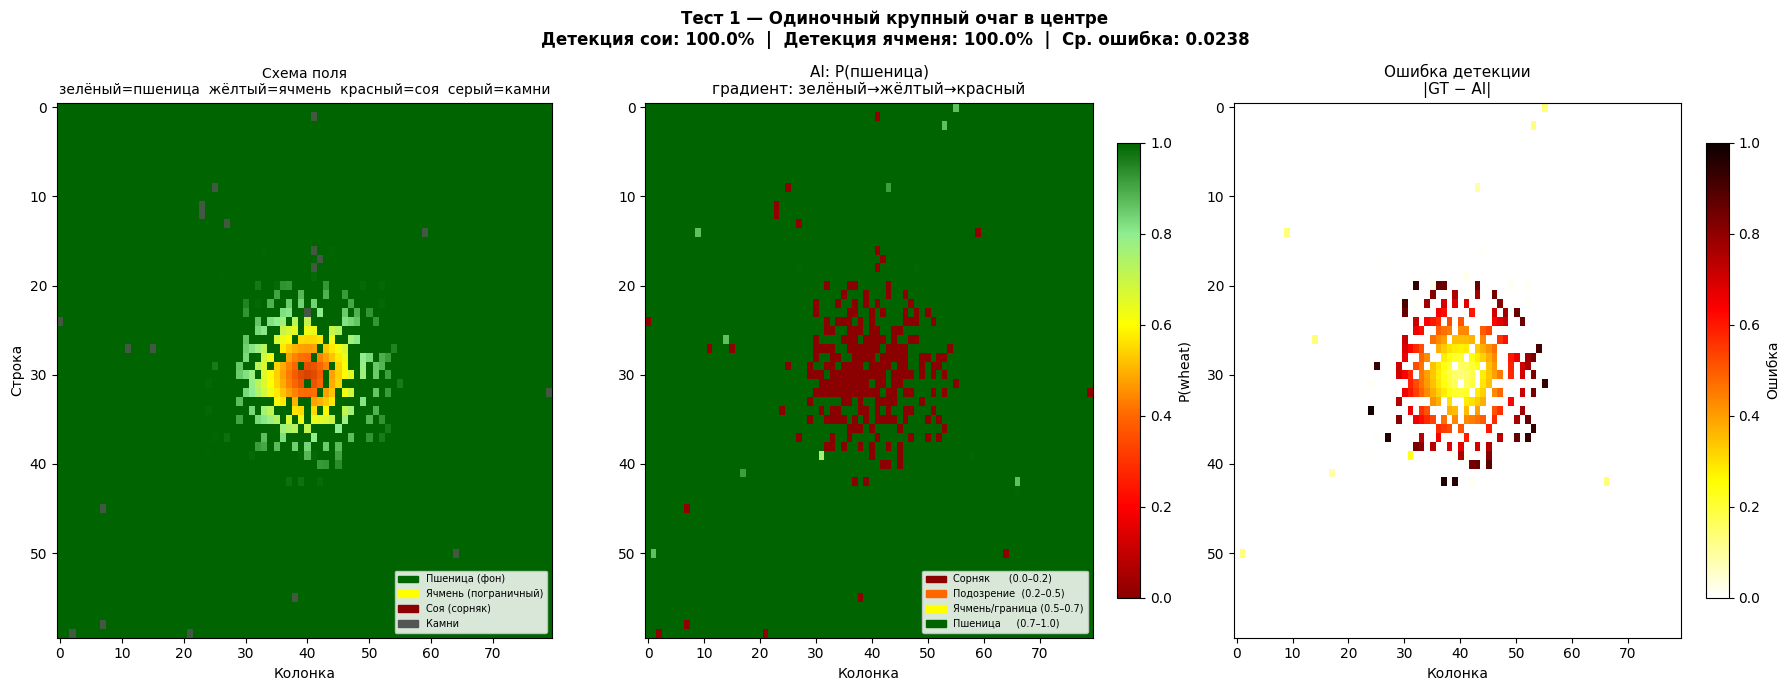

  Соя: 100.0% | Ячмень: 100.0% | Ошибка: 0.0238

[2/6] Тест 2 — Множество мелких очагов (ранняя стадия)...


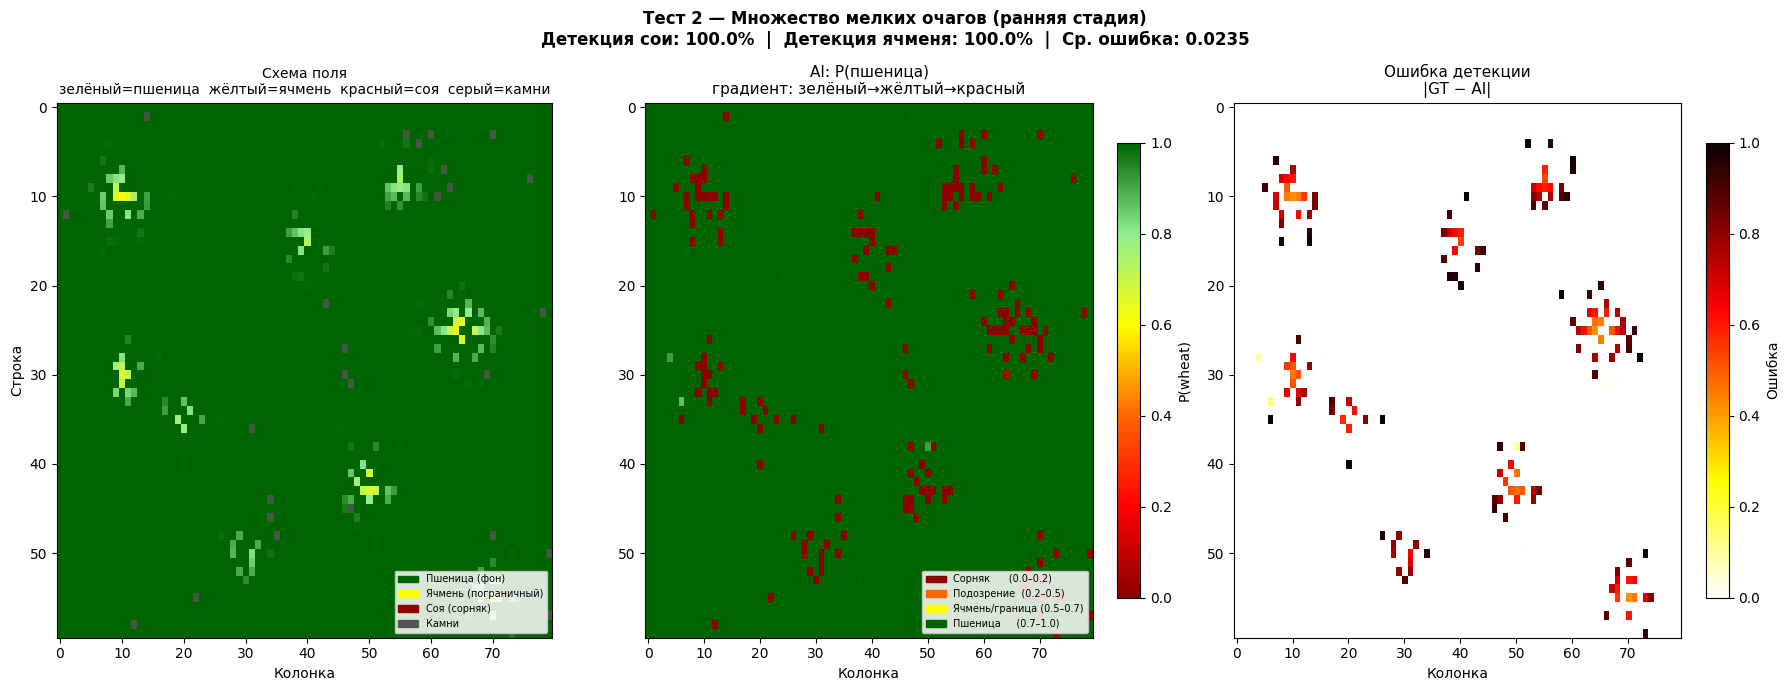

  Соя: 100.0% | Ячмень: 100.0% | Ошибка: 0.0235

[3/6] Тест 3 — Полосы сорняка вдоль рядов...


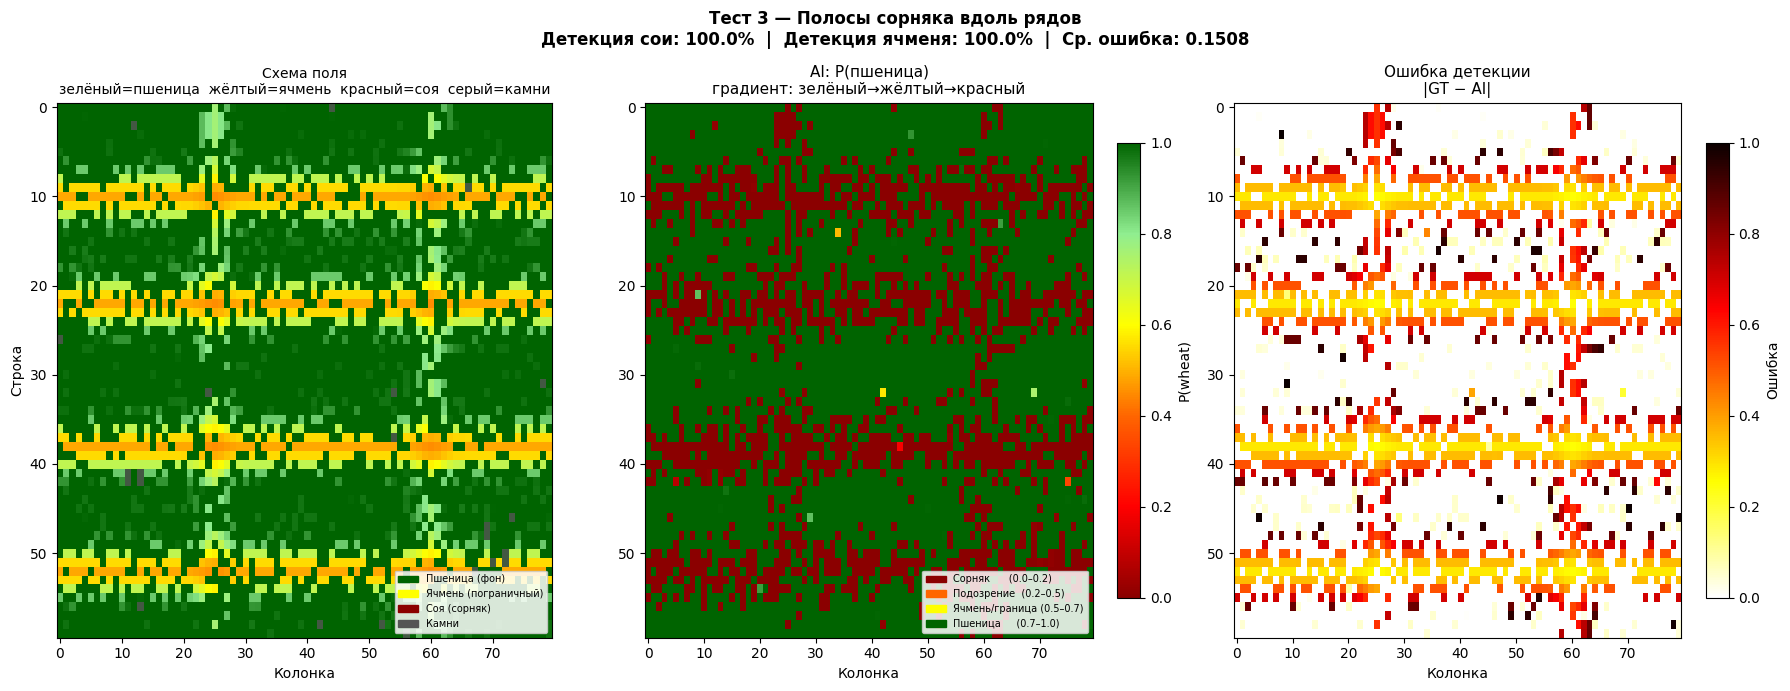

  Соя: 100.0% | Ячмень: 100.0% | Ошибка: 0.1508

[4/6] Тест 4 — Краевое заражение с севера...


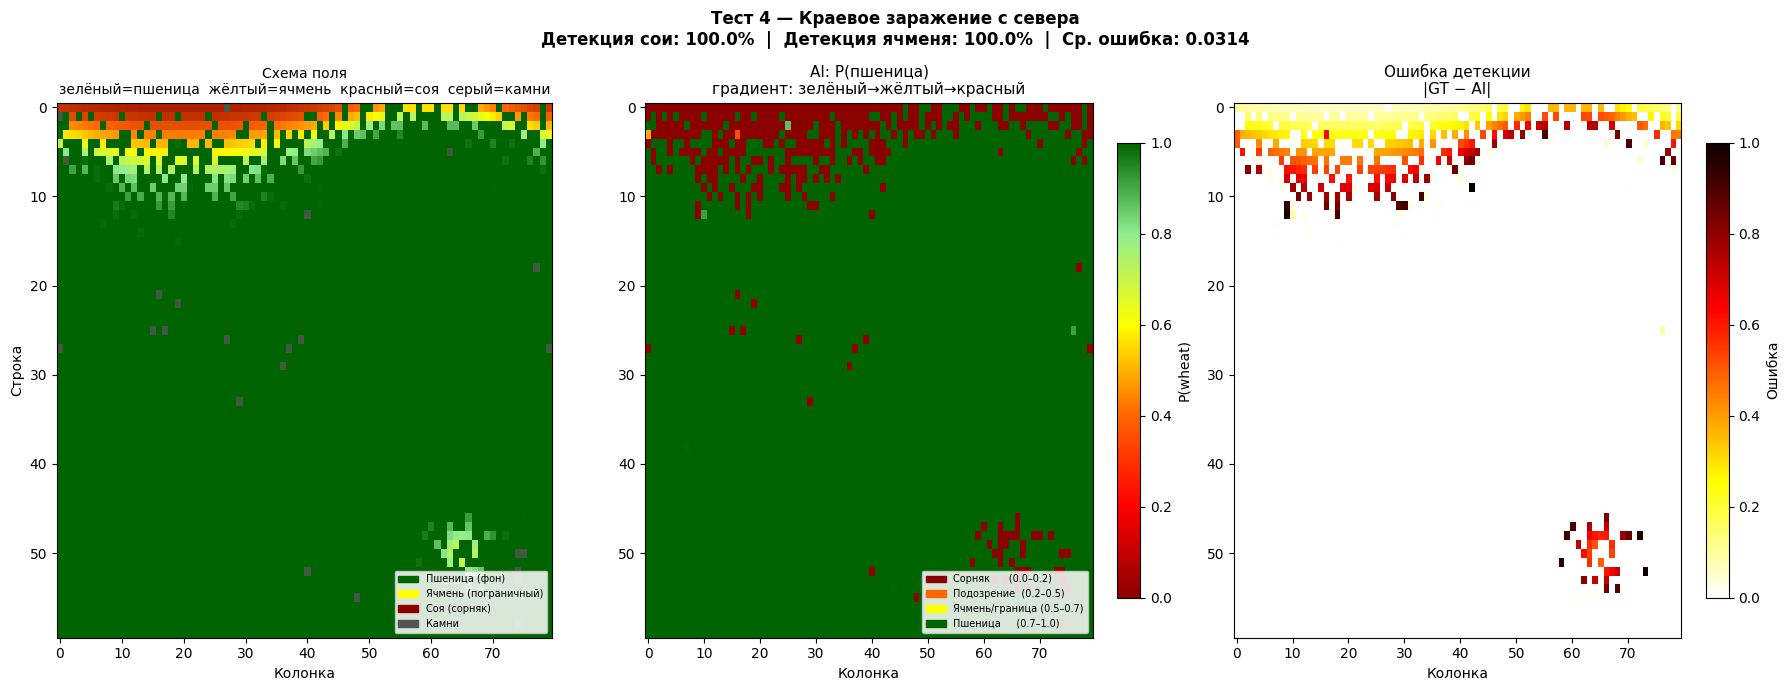

  Соя: 100.0% | Ячмень: 100.0% | Ошибка: 0.0314

[5/6] Тест 5 — Диагональный ветровой занос...


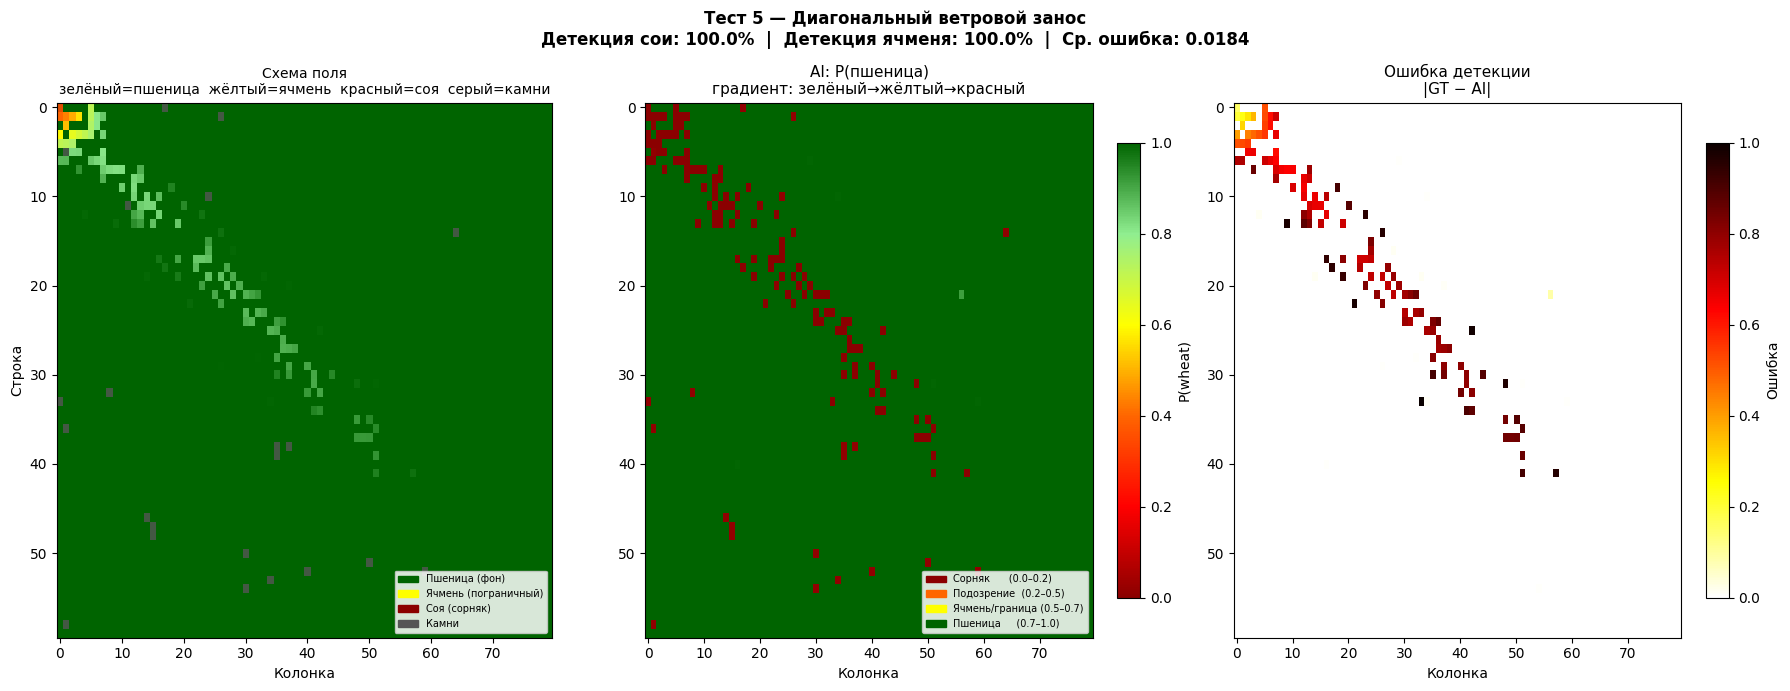

  Соя: 100.0% | Ячмень: 100.0% | Ошибка: 0.0184

[6/6] Тест 6 — Хаотичное заражение (запущенное поле)...


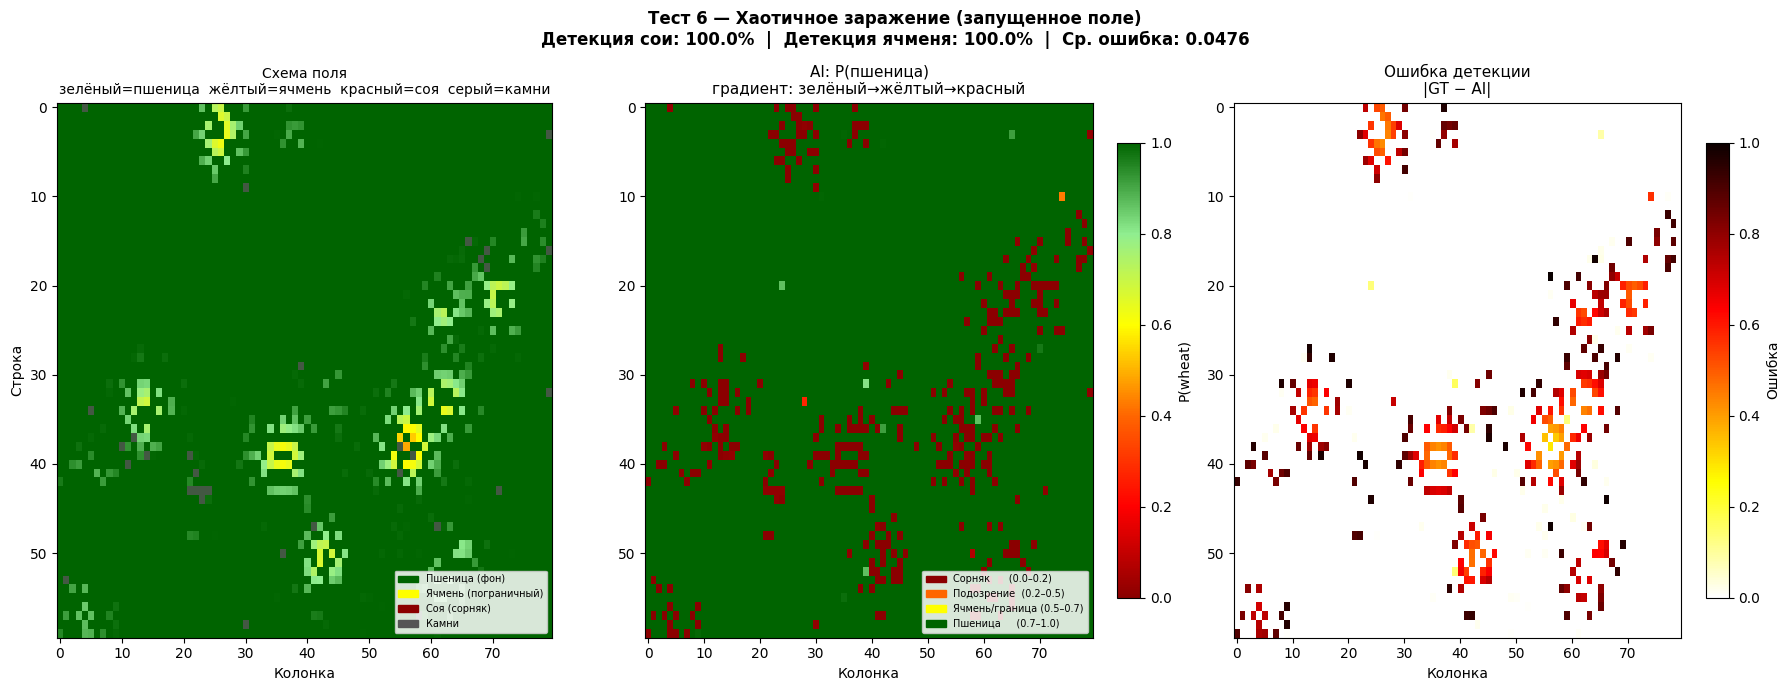

  Соя: 100.0% | Ячмень: 100.0% | Ошибка: 0.0476

Сценарий                                       Соя   Ячмень   Ошибка
Тест 1 — Одиночный крупный очаг в центре    100.0%    100.0%    0.0238
Тест 2 — Множество мелких очагов (ранняя стадия)  100.0%    100.0%    0.0235
Тест 3 — Полосы сорняка вдоль рядов         100.0%    100.0%    0.1508
Тест 4 — Краевое заражение с севера         100.0%    100.0%    0.0314
Тест 5 — Диагональный ветровой занос        100.0%    100.0%    0.0184
Тест 6 — Хаотичное заражение (запущенное поле)  100.0%    100.0%    0.0476


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# ============================================================
# 1. МОДЕЛЬ (уже загружена — пропустите если в той же сессии)
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=None)
    old_conv    = model.conv1
    model.conv1 = nn.Conv2d(num_channels, old_conv.out_channels,
                            old_conv.kernel_size, old_conv.stride,
                            old_conv.padding, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model()
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/DroneAI_WheatClassifier/best_model.pth',
    map_location=device
))
model = model.to(device)
model.eval()
print("Модель загружена ✓")

# ============================================================
# 2. ЗАГРУЖАЕМ ТАЙЛЫ — теперь три класса
# ============================================================
TILES_PATH = '/content/tiles_balanced'
BASE_PATH  = '/content/dataset/Component2-Processed UAV Imagery'
N_LOAD     = 2000
np.random.seed(42)

def load_tiles_from_dir(path, n):
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    np.random.shuffle(files)
    return [np.load(os.path.join(path, f)) for f in files[:n]]

def load_tiles_from_tiffs(crop_folder, n):
    """Загружает тайлы напрямую из tiff (для barley которого нет в tiles_balanced)"""
    tiles = []
    all_tiffs = []
    for plot_id in sorted(os.listdir(crop_folder)):
        plot_full = os.path.join(crop_folder, plot_id)
        if not os.path.isdir(plot_full): continue
        for f in sorted(os.listdir(plot_full)):
            if f.endswith('.tif'):
                all_tiffs.append(os.path.join(plot_full, f))

    import rasterio
    np.random.shuffle(all_tiffs)

    for tiff_path in all_tiffs:
        if len(tiles) >= n: break
        with rasterio.open(tiff_path) as src:
            data = src.read()
        _, H, W = data.shape
        indices = [(r,c) for r in range(H//64) for c in range(W//64)]
        np.random.shuffle(indices)
        for (ri, ci) in indices:
            if len(tiles) >= n: break
            tile = data[:, ri*64:(ri+1)*64, ci*64:(ci+1)*64]
            red = tile[2]
            if np.sum(red==0)/red.size > 0.3: continue
            ndvi = tile[5][red>0]
            if len(ndvi)==0 or ndvi.mean() < -0.05: continue
            if np.sum(red>=65530)/red.size > 0.5: continue
            tiles.append(tile.astype(np.float32))

    return tiles

print("Загружаю пшеницу...")
wheat_tiles  = load_tiles_from_dir(f'{TILES_PATH}/1', N_LOAD)
print(f"  Пшеница: {len(wheat_tiles)} ✓")

print("Загружаю сою (сильное заражение)...")
soy_tiles    = load_tiles_from_dir(f'{TILES_PATH}/0', N_LOAD)
print(f"  Соя: {len(soy_tiles)} ✓")

print("Загружаю ячмень (пограничный случай)...")
barley_tiles = load_tiles_from_tiffs(f'{BASE_PATH}/barley', N_LOAD)
print(f"  Ячмень: {len(barley_tiles)} ✓")

# ============================================================
# 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================
cmap_ai = mcolors.LinearSegmentedColormap.from_list(
    'field',
    [(0.0, '#8B0000'), (0.2, '#FF0000'), (0.4, '#FF6600'),
     (0.6, '#FFFF00'), (0.8, '#90EE90'), (1.0, '#006400')]
)

# GT карта: зелёный=пшеница, жёлтый=ячмень, красный=соя
cmap_gt = mcolors.LinearSegmentedColormap.from_list(
    'gt_map',
    [(0.0, '#006400'),   # чистая пшеница
     (0.4, '#90EE90'),   # пшеница с примесью
     (0.6, '#FFFF00'),   # ячмень (пограничный)
     (0.8, '#FF6600'),   # лёгкое заражение соей
     (1.0, '#8B0000')]   # сильное заражение соей
)

def normalize_tile(tile):
    t = np.zeros_like(tile, dtype=np.float32)
    t[:5] = tile[:5] / 65535.0
    t[5]  = (tile[5] + 1.0) / 2.0
    return np.clip(t, 0.0, 1.0)

def run_inference_on_grid(tile_grid, rows, cols):
    prob_map = np.zeros((rows, cols))
    batch_t, batch_c = [], []

    def flush(bt, bc):
        b = torch.stack(bt).to(device)
        with torch.no_grad():
            p = torch.softmax(model(b), dim=1)[:, 1].cpu().numpy()
        for (r, c), prob in zip(bc, p):
            prob_map[r, c] = prob

    for r in range(rows):
        for c in range(cols):
            batch_t.append(torch.from_numpy(normalize_tile(tile_grid[r][c])))
            batch_c.append((r, c))
            if len(batch_t) == 256:
                flush(batch_t, batch_c)
                batch_t.clear(); batch_c.clear()
    if batch_t:
        flush(batch_t, batch_c)
    return prob_map

def add_rocks(rows, cols, n_clusters=3, rocks_per_cluster=4):
    rock_mask = np.zeros((rows, cols), dtype=bool)
    for _ in range(8):
        rock_mask[np.random.randint(2,rows-2), np.random.randint(2,cols-2)] = True
    for _ in range(n_clusters):
        cr, cc = np.random.randint(5,rows-5), np.random.randint(5,cols-5)
        for _ in range(rocks_per_cluster):
            rr = np.clip(cr+np.random.randint(-2,3), 0, rows-1)
            rc = np.clip(cc+np.random.randint(-2,3), 0, cols-1)
            rock_mask[rr, rc] = True
    for _ in range(6):
        edge = np.random.choice(['top','bot','left','right'])
        if   edge=='top':   r,c = np.random.randint(0,2),        np.random.randint(0,cols)
        elif edge=='bot':   r,c = np.random.randint(rows-2,rows), np.random.randint(0,cols)
        elif edge=='left':  r,c = np.random.randint(0,rows),      np.random.randint(0,2)
        else:               r,c = np.random.randint(0,rows),      np.random.randint(cols-2,cols)
        rock_mask[r, c] = True
    return rock_mask

def build_field(soy_map, barley_map, rock_mask, rows, cols):
    """
    Три слоя заражения:
    - soy_map:    вероятность сои    (сильное заражение, P=0.0–0.2 у модели)
    - barley_map: вероятность ячменя (пограничный,       P=0.3–0.7 у модели)
    - rock_mask:  камни              (аномалии без заражения)
    """
    soy_idx    = np.random.randint(0, len(soy_tiles),    (rows, cols))
    barley_idx = np.random.randint(0, len(barley_tiles), (rows, cols))
    wheat_idx  = np.random.randint(0, len(wheat_tiles),  (rows, cols))

    rock_tile      = soy_tiles[0].copy()
    rock_tile[5]   = -0.9

    grid     = []
    true_inf = np.zeros((rows, cols))  # 0=пшеница, 0.5=ячмень, 1.0=соя

    for r in range(rows):
        row = []
        for c in range(cols):
            if rock_mask[r, c]:
                row.append(rock_tile)
                true_inf[r, c] = -0.1  # камень
            elif np.random.random() < soy_map[r, c]:
                row.append(soy_tiles[soy_idx[r, c]])
                true_inf[r, c] = soy_map[r, c]        # сильное (0.5–1.0)
            elif np.random.random() < barley_map[r, c]:
                row.append(barley_tiles[barley_idx[r, c]])
                true_inf[r, c] = barley_map[r, c] * 0.5  # пограничное (0.2–0.5)
            else:
                row.append(wheat_tiles[wheat_idx[r, c]])
        grid.append(row)
    return grid, true_inf

def make_map(rows, cols, fn):
    return np.clip(gaussian_filter(fn(rows, cols), sigma=1.5), 0, 1)

def plot_test(prob_map, true_inf, rock_mask, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    # --- GT: правильные цвета ---
    # 0=пшеница(зелёный), 0.5=ячмень(жёлтый), 1.0=соя(красный), -0.1=камень(серый)
    gt_display = true_inf.copy()
    axes[0].imshow(gt_display, cmap=cmap_gt, vmin=0, vmax=1,
                   interpolation='nearest', aspect='auto')
    # Камни поверх отдельным слоем
    rock_overlay = np.ma.masked_where(~rock_mask, np.ones_like(true_inf))
    axes[0].imshow(rock_overlay, cmap=mcolors.ListedColormap(['#555555']),
                   vmin=0, vmax=1, interpolation='nearest', aspect='auto', alpha=0.8)
    axes[0].set_title('Схема поля\nзелёный=пшеница  жёлтый=ячмень  красный=соя  серый=камни',
                      fontsize=10)
    axes[0].set_xlabel('Колонка'); axes[0].set_ylabel('Строка')
    axes[0].legend(handles=[
        Patch(color='#006400', label='Пшеница (фон)'),
        Patch(color='#FFFF00', label='Ячмень (пограничный)'),
        Patch(color='#8B0000', label='Соя (сорняк)'),
        Patch(color='#555555', label='Камни'),
    ], loc='lower right', fontsize=7, framealpha=0.85)

    # --- AI карта ---
    im = axes[1].imshow(prob_map, cmap=cmap_ai, vmin=0, vmax=1,
                        interpolation='nearest', aspect='auto')
    axes[1].set_title('AI: P(пшеница)\nградиент: зелёный→жёлтый→красный', fontsize=11)
    axes[1].set_xlabel('Колонка')
    plt.colorbar(im, ax=axes[1], fraction=0.046, label='P(wheat)')
    axes[1].legend(handles=[
        Patch(color='#8B0000', label='Сорняк      (0.0–0.2)'),
        Patch(color='#FF6600', label='Подозрение  (0.2–0.5)'),
        Patch(color='#FFFF00', label='Ячмень/граница (0.5–0.7)'),
        Patch(color='#006400', label='Пшеница     (0.7–1.0)'),
    ], loc='lower right', fontsize=7, framealpha=0.85)

    # --- Карта ошибок ---
    threat = 1.0 - prob_map
    gt_norm = np.clip(true_inf, 0, 1)
    diff = np.abs(gt_norm - threat)
    diff[rock_mask] = 0
    im3 = axes[2].imshow(diff, cmap='hot_r', vmin=0, vmax=1,
                         interpolation='nearest', aspect='auto')
    axes[2].set_title('Ошибка детекции\n|GT − AI|', fontsize=11)
    axes[2].set_xlabel('Колонка')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, label='Ошибка')

    # Статистика
    soy_mask    = true_inf > 0.4
    barley_mask = (true_inf > 0.1) & (true_inf <= 0.4)
    det_soy     = (prob_map[soy_mask] < 0.4).sum() / soy_mask.sum() * 100 if soy_mask.sum() > 0 else 0
    det_barley  = (prob_map[barley_mask] < 0.65).sum() / barley_mask.sum() * 100 if barley_mask.sum() > 0 else 0
    mean_err    = diff[~rock_mask].mean()

    plt.suptitle(f'{title}\n'
                 f'Детекция сои: {det_soy:.1f}%  |  '
                 f'Детекция ячменя: {det_barley:.1f}%  |  '
                 f'Ср. ошибка: {mean_err:.4f}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/{filename}', dpi=110, bbox_inches='tight')
    plt.show()
    print(f"  Соя: {det_soy:.1f}% | Ячмень: {det_barley:.1f}% | Ошибка: {mean_err:.4f}")
    return det_soy, det_barley, mean_err

# ============================================================
# 4. ШЕСТЬ ТЕСТОВ
# ============================================================
ROWS, COLS = 60, 80
results    = []

def p1(R,C):
    m=np.zeros((R,C))
    for r in range(R):
        for c in range(C):
            d=np.sqrt(((r-R//2)/12)**2+((c-C//2)/16)**2)
            if d<1: m[r,c]=1.0-d
    return m

def p2(R,C):
    m=np.zeros((R,C))
    for (cr,cc,rr,rc) in [(10,10,4,5),(15,40,3,4),(25,65,4,6),(35,20,3,4),
                           (42,50,4,5),(50,30,3,3),(55,70,4,5),(8,55,3,4),(30,10,4,4)]:
        for r in range(R):
            for c in range(C):
                d=np.sqrt(((r-cr)/rr)**2+((c-cc)/rc)**2)
                if d<1: m[r,c]=max(m[r,c],1.0-d)
    return m

def p3(R,C):
    m=np.zeros((R,C))
    for sr in [10,22,38,52]:
        for r in range(R):
            d=abs(r-sr)
            if d<4: m[r,:]=np.maximum(m[r,:],1.0-d/4)
    for sc in [25,60]:
        for c in range(C):
            d=abs(c-sc)
            if d<3: m[:,c]=np.maximum(m[:,c],0.7-d/3*0.7)
    return m

def p4(R,C):
    m=np.zeros((R,C))
    for c in range(C):
        depth=int(8+6*np.sin(c/C*2*np.pi))
        for r in range(depth): m[r,c]=max(0,1.0-r/depth)
    for r in range(R):
        for c in range(C):
            d=np.sqrt(((r-50)/5)**2+((c-65)/7)**2)
            if d<1: m[r,c]=max(m[r,c],0.8*(1-d))
    return m

def p5(R,C):
    m=np.zeros((R,C))
    for r in range(R):
        for c in range(C):
            d=np.sqrt((r/8)**2+(c/10)**2)
            if d<1: m[r,c]=max(m[r,c],1.0-d)
    for r in range(R):
        for c in range(C):
            diag=abs((r/R)-(c/C)); along=(r+c)/(R+C)
            if diag<0.08 and along<0.7:
                m[r,c]=max(m[r,c],0.6*(1-along)*(1-diag/0.08))
    return m

def p6(R,C):
    m=np.zeros((R,C)); np.random.seed(99)
    for _ in range(18):
        cr=np.random.randint(3,R-3); cc=np.random.randint(3,C-3)
        rr=np.random.randint(2,9);   rc=np.random.randint(2,9)
        intensity=np.random.uniform(0.4,1.0)
        for r in range(R):
            for c in range(C):
                d=np.sqrt(((r-cr)/rr)**2+((c-cc)/rc)**2)
                if d<1: m[r,c]=max(m[r,c],intensity*(1-d))
    return m

scenarios = [
    (p1, "Тест 1 — Одиночный крупный очаг в центре",      "test1.png", 2, 3),
    (p2, "Тест 2 — Множество мелких очагов (ранняя стадия)", "test2.png", 4, 3),
    (p3, "Тест 3 — Полосы сорняка вдоль рядов",           "test3.png", 2, 5),
    (p4, "Тест 4 — Краевое заражение с севера",            "test4.png", 3, 4),
    (p5, "Тест 5 — Диагональный ветровой занос",           "test5.png", 3, 3),
    (p6, "Тест 6 — Хаотичное заражение (запущенное поле)", "test6.png", 5, 4),
]

for i, (pfn, title, fname, nc, rpc) in enumerate(scenarios, 1):
    print(f"\n[{i}/6] {title}...")
    soy_inf    = make_map(ROWS, COLS, pfn)
    # Ячмень — ореол вокруг очагов сои (переходная зона)
    barley_inf = make_map(ROWS, COLS,
                          lambda R,C,s=soy_inf: gaussian_filter(s, sigma=3.0) * 0.6)
    barley_inf = np.clip(barley_inf - soy_inf * 0.5, 0, 1)
    rocks      = add_rocks(ROWS, COLS, nc, rpc)
    grid, ti   = build_field(soy_inf, barley_inf, rocks, ROWS, COLS)
    prob       = run_inference_on_grid(grid, ROWS, COLS)
    r = plot_test(prob, ti, rocks, title, fname)
    results.append((title, *r))

# ============================================================
# 5. СВОДНАЯ ТАБЛИЦА
# ============================================================
print(f"\n{'='*65}")
print(f"{'Сценарий':<42} {'Соя':>7} {'Ячмень':>8} {'Ошибка':>8}")
print(f"{'='*65}")
for name, ds, db, err in results:
    print(f"{name:<42} {ds:>6.1f}%  {db:>7.1f}%  {err:>8.4f}")
print(f"{'='*65}")

Модель загружена ✓
Загружаю пшеницу...
  Пшеница: 2000 ✓
Загружаю сорняк сильный...
  Сорняк (сильный): 2000 ✓
Загружаю сорняк слабый (пограничный)...
  Сорняк (слабый/пограничный): 2000 ✓

[1/6] Тест 1 — Одиночный крупный очаг в центре поля...


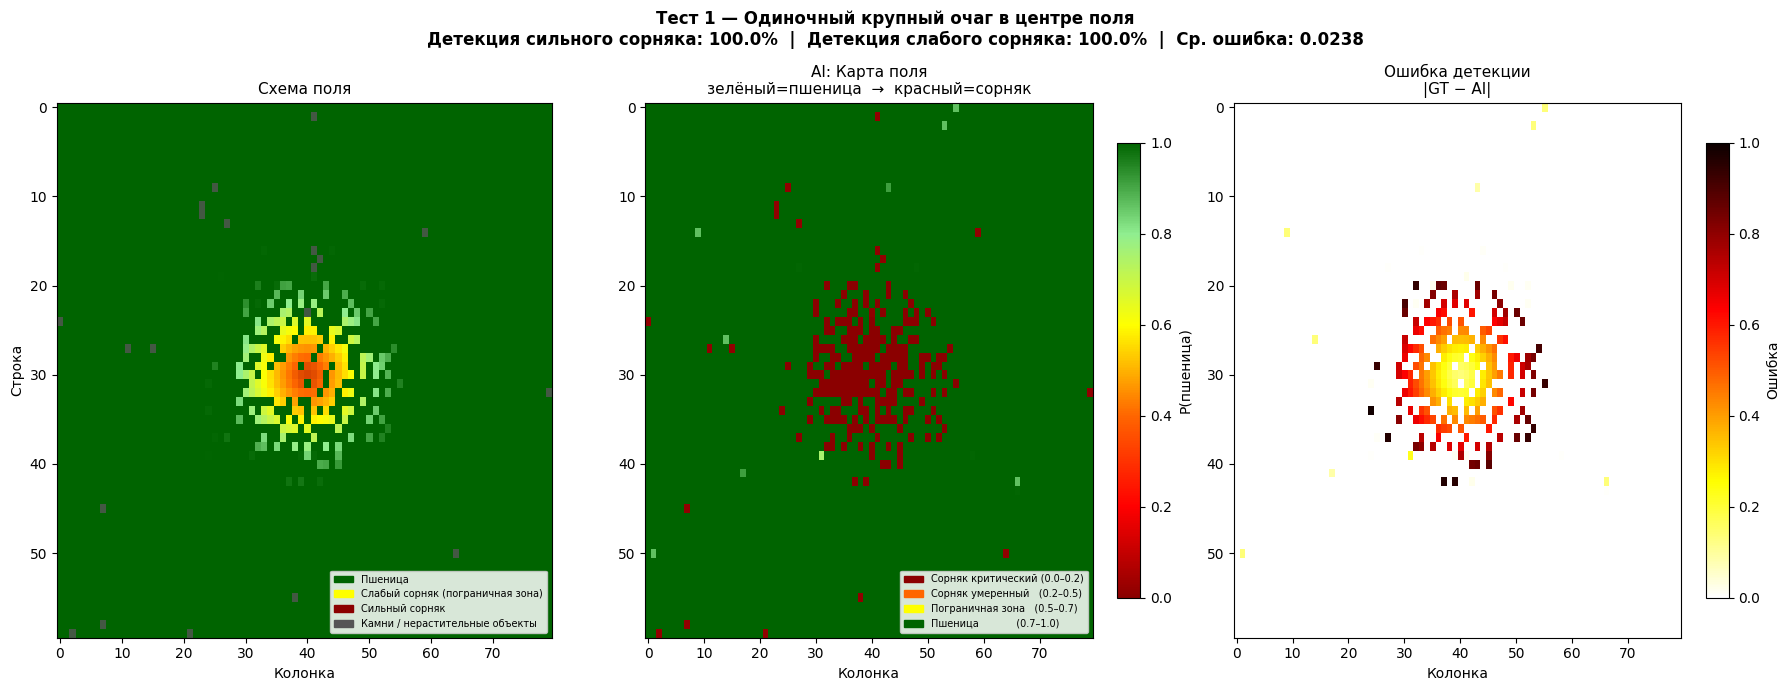

  Сильный: 100.0% | Слабый: 100.0% | Ошибка: 0.0238

[2/6] Тест 2 — Множество мелких очагов (ранняя стадия)...


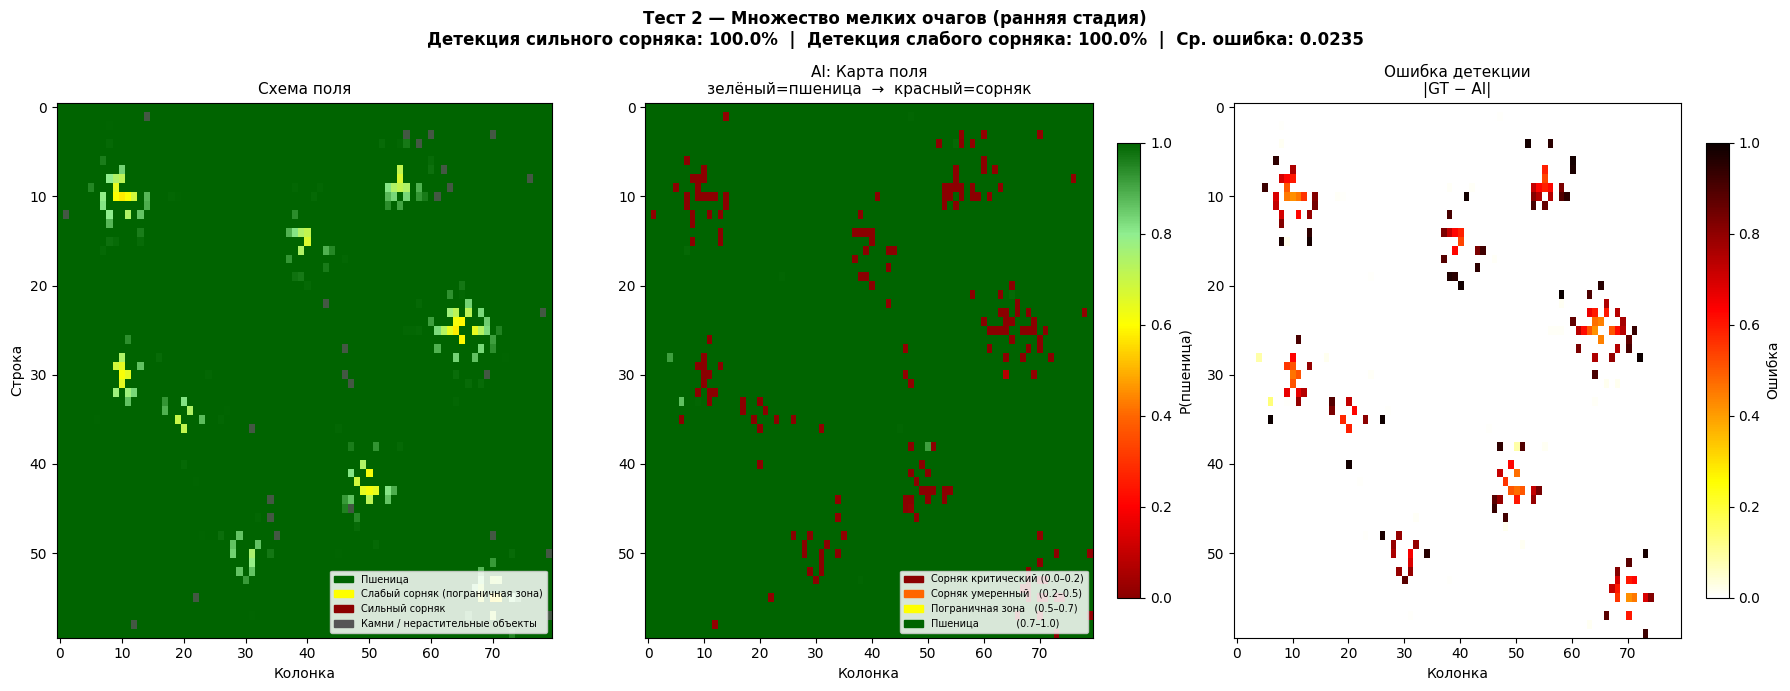

  Сильный: 100.0% | Слабый: 100.0% | Ошибка: 0.0235

[3/6] Тест 3 — Полосы сорняка вдоль рядов...


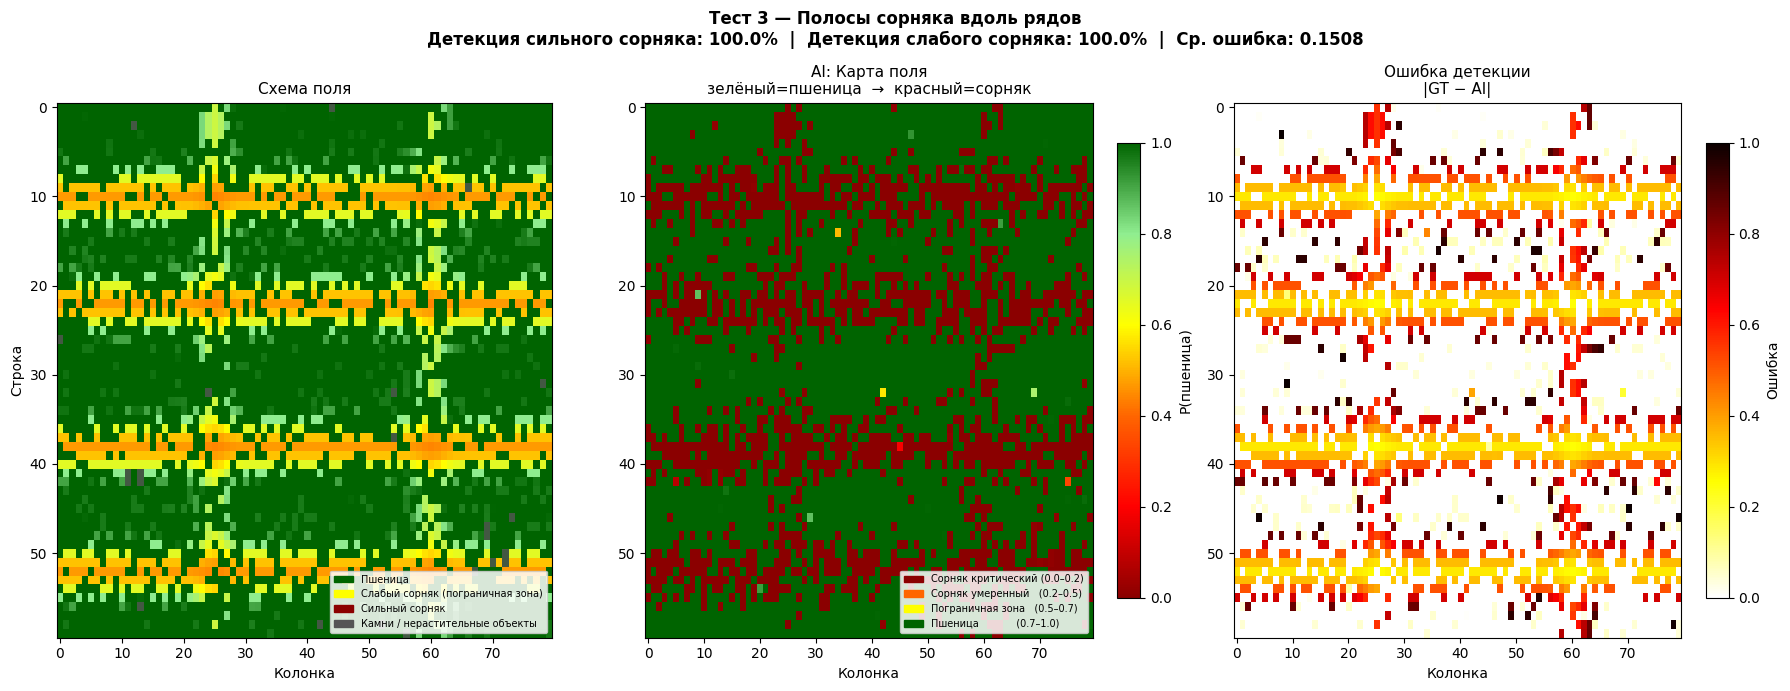

  Сильный: 100.0% | Слабый: 100.0% | Ошибка: 0.1508

[4/6] Тест 4 — Краевое заражение с волнистым фронтом...


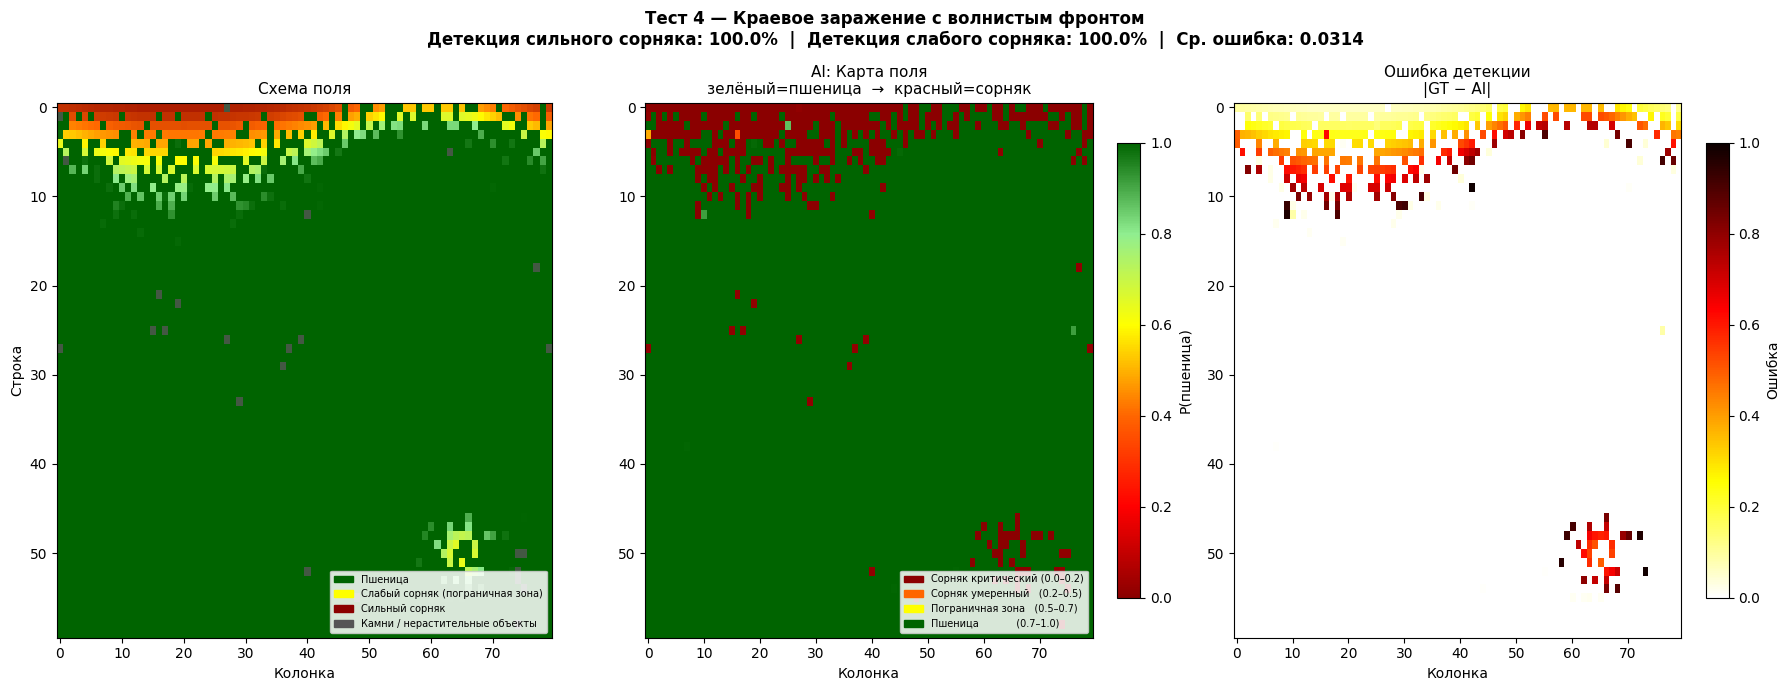

  Сильный: 100.0% | Слабый: 100.0% | Ошибка: 0.0314

[5/6] Тест 5 — Диагональный ветровой занос...


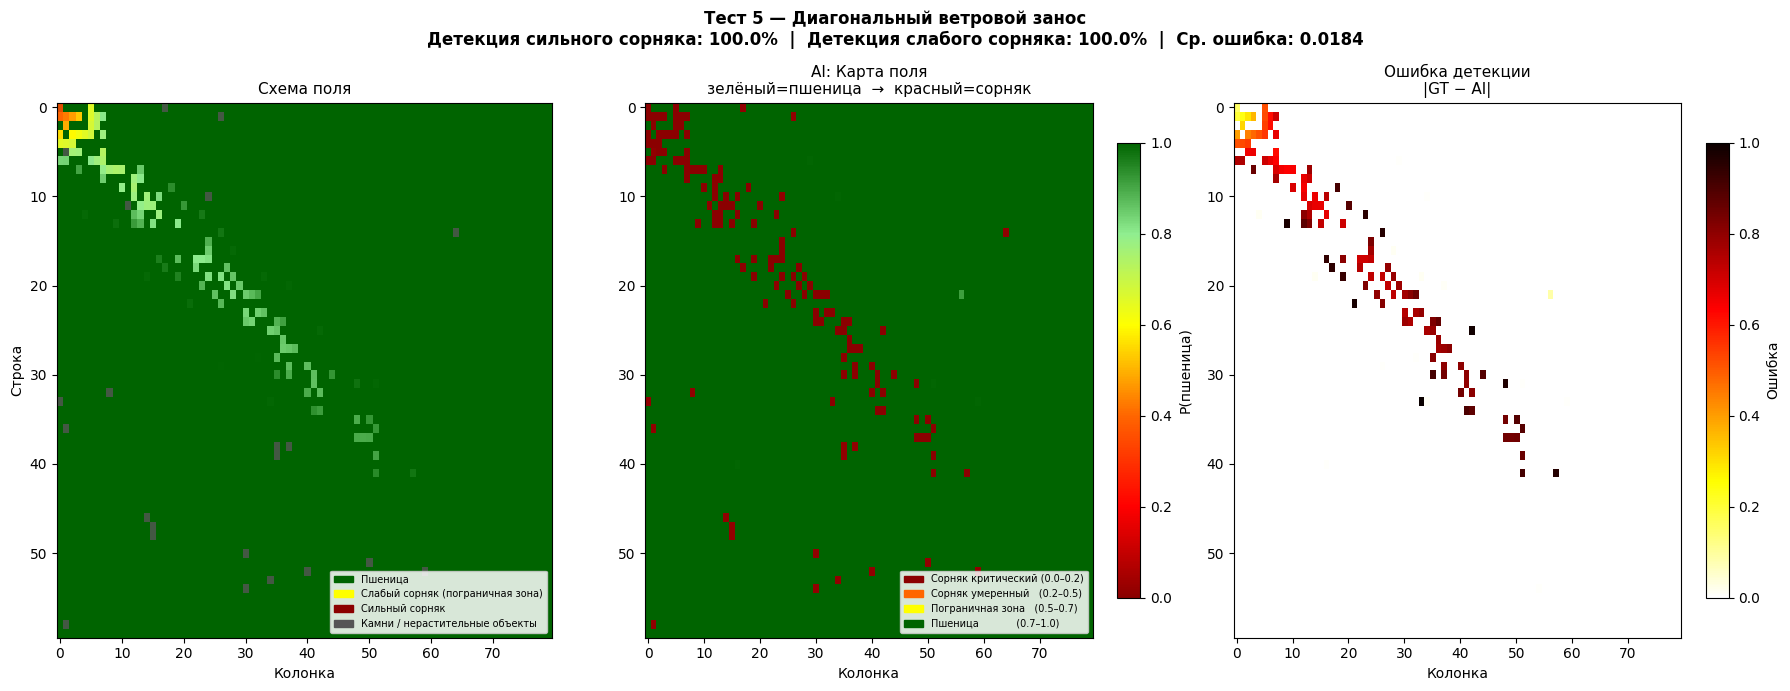

  Сильный: 100.0% | Слабый: 100.0% | Ошибка: 0.0184

[6/6] Тест 6 — Хаотичное заражение (запущенное поле)...


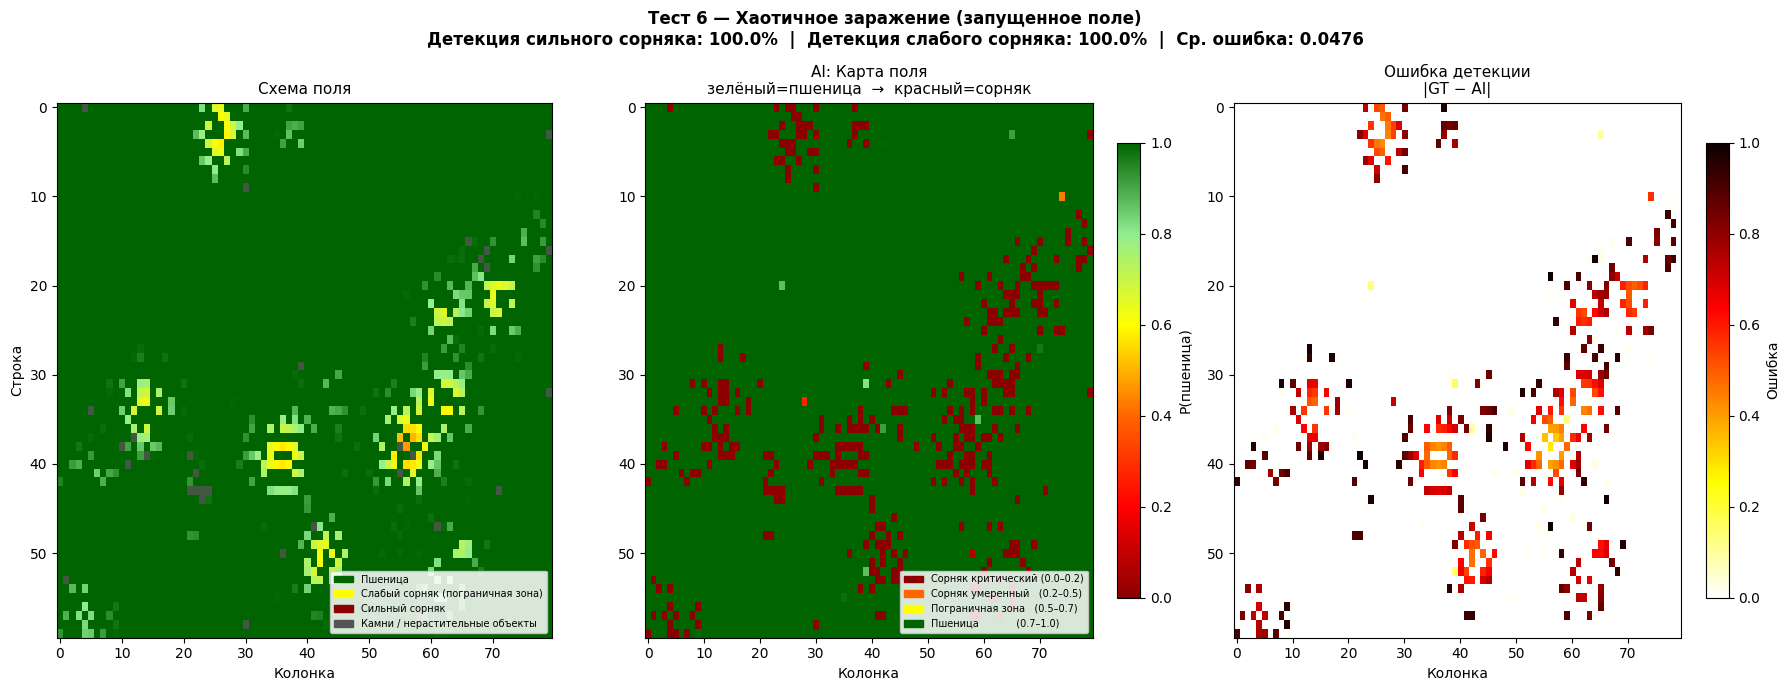

  Сильный: 100.0% | Слабый: 100.0% | Ошибка: 0.0476

Сценарий                                      Сильный   Слабый   Ошибка
Тест 1 — Одиночный крупный очаг в центре поля   100.0%    100.0%    0.0238
Тест 2 — Множество мелких очагов (ранняя стадия)   100.0%    100.0%    0.0235
Тест 3 — Полосы сорняка вдоль рядов            100.0%    100.0%    0.1508
Тест 4 — Краевое заражение с волнистым фронтом   100.0%    100.0%    0.0314
Тест 5 — Диагональный ветровой занос           100.0%    100.0%    0.0184
Тест 6 — Хаотичное заражение (запущенное поле)   100.0%    100.0%    0.0476


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter

# ============================================================
# 1. МОДЕЛЬ
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(num_channels=6, num_classes=2):
    model = models.resnet18(weights=None)
    old_conv    = model.conv1
    model.conv1 = nn.Conv2d(num_channels, old_conv.out_channels,
                            old_conv.kernel_size, old_conv.stride,
                            old_conv.padding, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model()
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/DroneAI_WheatClassifier/best_model.pth',
    map_location=device
))
model = model.to(device)
model.eval()
print("Модель загружена ✓")

# ============================================================
# 2. ЗАГРУЖАЕМ ТАЙЛЫ — пшеница / сорняк слабый / сорняк сильный
# ============================================================
TILES_PATH = '/content/tiles_balanced'
BASE_PATH  = '/content/dataset/Component2-Processed UAV Imagery'
N_LOAD     = 2000
np.random.seed(42)

def load_tiles_from_dir(path, n):
    files = [f for f in os.listdir(path) if f.endswith('.npy')]
    np.random.shuffle(files)
    return [np.load(os.path.join(path, f)) for f in files[:n]]

def load_tiles_from_tiffs(crop_folder, n):
    import rasterio
    tiles = []
    all_tiffs = []
    for plot_id in sorted(os.listdir(crop_folder)):
        plot_full = os.path.join(crop_folder, plot_id)
        if not os.path.isdir(plot_full): continue
        for f in sorted(os.listdir(plot_full)):
            if f.endswith('.tif'):
                all_tiffs.append(os.path.join(plot_full, f))
    np.random.shuffle(all_tiffs)
    for tiff_path in all_tiffs:
        if len(tiles) >= n: break
        with rasterio.open(tiff_path) as src:
            data = src.read()
        _, H, W = data.shape
        indices = [(r,c) for r in range(H//64) for c in range(W//64)]
        np.random.shuffle(indices)
        for (ri, ci) in indices:
            if len(tiles) >= n: break
            tile = data[:, ri*64:(ri+1)*64, ci*64:(ci+1)*64]
            red = tile[2]
            if np.sum(red==0)/red.size > 0.3: continue
            ndvi = tile[5][red>0]
            if len(ndvi)==0 or ndvi.mean() < -0.05: continue
            if np.sum(red>=65530)/red.size > 0.5: continue
            tiles.append(tile.astype(np.float32))
    return tiles

print("Загружаю пшеницу...")
wheat_tiles  = load_tiles_from_dir(f'{TILES_PATH}/1', N_LOAD)
print(f"  Пшеница: {len(wheat_tiles)} ✓")

print("Загружаю сорняк сильный...")
weed_strong  = load_tiles_from_dir(f'{TILES_PATH}/0', N_LOAD)
print(f"  Сорняк (сильный): {len(weed_strong)} ✓")

print("Загружаю сорняк слабый (пограничный)...")
weed_weak    = load_tiles_from_tiffs(f'{BASE_PATH}/barley', N_LOAD)
print(f"  Сорняк (слабый/пограничный): {len(weed_weak)} ✓")

# ============================================================
# 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================
# AI карта: 0=сорняк(красный) → 1=пшеница(зелёный)
cmap_ai = mcolors.LinearSegmentedColormap.from_list(
    'field',
    [(0.0, '#8B0000'), (0.2, '#FF0000'), (0.4, '#FF6600'),
     (0.6, '#FFFF00'), (0.8, '#90EE90'), (1.0, '#006400')]
)

# GT карта: 0=пшеница(зелёный) → 1=сорняк(красный)
cmap_gt = mcolors.LinearSegmentedColormap.from_list(
    'gt_map',
    [(0.0, '#006400'),   # чистая пшеница
     (0.3, '#90EE90'),   # пшеница с лёгкой примесью
     (0.55, '#FFFF00'),  # слабый сорняк (пограничная зона)
     (0.8, '#FF6600'),   # умеренный сорняк
     (1.0, '#8B0000')]   # сильный сорняк
)

def normalize_tile(tile):
    t = np.zeros_like(tile, dtype=np.float32)
    t[:5] = tile[:5] / 65535.0
    t[5]  = (tile[5] + 1.0) / 2.0
    return np.clip(t, 0.0, 1.0)

def run_inference_on_grid(tile_grid, rows, cols):
    prob_map = np.zeros((rows, cols))
    batch_t, batch_c = [], []

    def flush(bt, bc):
        b = torch.stack(bt).to(device)
        with torch.no_grad():
            p = torch.softmax(model(b), dim=1)[:, 1].cpu().numpy()
        for (r, c), prob in zip(bc, p):
            prob_map[r, c] = prob

    for r in range(rows):
        for c in range(cols):
            batch_t.append(torch.from_numpy(normalize_tile(tile_grid[r][c])))
            batch_c.append((r, c))
            if len(batch_t) == 256:
                flush(batch_t, batch_c)
                batch_t.clear(); batch_c.clear()
    if batch_t:
        flush(batch_t, batch_c)
    return prob_map

def add_rocks(rows, cols, n_clusters=3, rocks_per_cluster=4):
    rock_mask = np.zeros((rows, cols), dtype=bool)
    for _ in range(8):
        rock_mask[np.random.randint(2,rows-2), np.random.randint(2,cols-2)] = True
    for _ in range(n_clusters):
        cr, cc = np.random.randint(5,rows-5), np.random.randint(5,cols-5)
        for _ in range(rocks_per_cluster):
            rr = np.clip(cr+np.random.randint(-2,3), 0, rows-1)
            rc = np.clip(cc+np.random.randint(-2,3), 0, cols-1)
            rock_mask[rr, rc] = True
    for _ in range(6):
        edge = np.random.choice(['top','bot','left','right'])
        if   edge=='top':  r,c = np.random.randint(0,2),         np.random.randint(0,cols)
        elif edge=='bot':  r,c = np.random.randint(rows-2,rows),  np.random.randint(0,cols)
        elif edge=='left': r,c = np.random.randint(0,rows),       np.random.randint(0,2)
        else:              r,c = np.random.randint(0,rows),       np.random.randint(cols-2,cols)
        rock_mask[r, c] = True
    return rock_mask

def build_field(strong_map, weak_map, rock_mask, rows, cols):
    strong_idx = np.random.randint(0, len(weed_strong), (rows, cols))
    weak_idx   = np.random.randint(0, len(weed_weak),   (rows, cols))
    wheat_idx  = np.random.randint(0, len(wheat_tiles), (rows, cols))
    rock_tile  = weed_strong[0].copy()
    rock_tile[5] = -0.9

    grid, true_inf = [], np.zeros((rows, cols))
    for r in range(rows):
        row = []
        for c in range(cols):
            if rock_mask[r, c]:
                row.append(rock_tile)
                true_inf[r, c] = -0.1   # камень — вне шкалы
            elif np.random.random() < strong_map[r, c]:
                row.append(weed_strong[strong_idx[r, c]])
                true_inf[r, c] = strong_map[r, c]           # 0.5–1.0
            elif np.random.random() < weak_map[r, c]:
                row.append(weed_weak[weak_idx[r, c]])
                true_inf[r, c] = weak_map[r, c] * 0.5      # 0.2–0.5
            else:
                row.append(wheat_tiles[wheat_idx[r, c]])
        grid.append(row)
    return grid, true_inf

def make_map(rows, cols, fn):
    return np.clip(gaussian_filter(fn(rows, cols), sigma=1.5), 0, 1)

def plot_test(prob_map, true_inf, rock_mask, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    # --- GT ---
    axes[0].imshow(true_inf, cmap=cmap_gt, vmin=0, vmax=1,
                   interpolation='nearest', aspect='auto')
    rock_overlay = np.ma.masked_where(~rock_mask, np.ones_like(true_inf))
    axes[0].imshow(rock_overlay, cmap=mcolors.ListedColormap(['#555555']),
                   vmin=0, vmax=1, interpolation='nearest', aspect='auto', alpha=0.8)
    axes[0].set_title('Схема поля', fontsize=11)
    axes[0].set_xlabel('Колонка'); axes[0].set_ylabel('Строка')
    axes[0].legend(handles=[
        Patch(color='#006400', label='Пшеница'),
        Patch(color='#FFFF00', label='Слабый сорняк (пограничная зона)'),
        Patch(color='#8B0000', label='Сильный сорняк'),
        Patch(color='#555555', label='Камни / нерастительные объекты'),
    ], loc='lower right', fontsize=7, framealpha=0.85)

    # --- AI карта ---
    im = axes[1].imshow(prob_map, cmap=cmap_ai, vmin=0, vmax=1,
                        interpolation='nearest', aspect='auto')
    axes[1].set_title('AI: Карта поля\nзелёный=пшеница  →  красный=сорняк', fontsize=11)
    axes[1].set_xlabel('Колонка')
    plt.colorbar(im, ax=axes[1], fraction=0.046, label='P(пшеница)')
    axes[1].legend(handles=[
        Patch(color='#8B0000', label='Сорняк критический (0.0–0.2)'),
        Patch(color='#FF6600', label='Сорняк умеренный   (0.2–0.5)'),
        Patch(color='#FFFF00', label='Пограничная зона   (0.5–0.7)'),
        Patch(color='#006400', label='Пшеница            (0.7–1.0)'),
    ], loc='lower right', fontsize=7, framealpha=0.85)

    # --- Ошибка ---
    threat  = 1.0 - prob_map
    gt_norm = np.clip(true_inf, 0, 1)
    diff    = np.abs(gt_norm - threat)
    diff[rock_mask] = 0
    im3 = axes[2].imshow(diff, cmap='hot_r', vmin=0, vmax=1,
                         interpolation='nearest', aspect='auto')
    axes[2].set_title('Ошибка детекции\n|GT − AI|', fontsize=11)
    axes[2].set_xlabel('Колонка')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, label='Ошибка')

    # Статистика
    strong_mask = true_inf > 0.4
    weak_mask   = (true_inf > 0.1) & (true_inf <= 0.4)
    det_strong  = (prob_map[strong_mask] < 0.4).sum() / strong_mask.sum() * 100 if strong_mask.sum() > 0 else 0
    det_weak    = (prob_map[weak_mask]   < 0.65).sum() / weak_mask.sum()   * 100 if weak_mask.sum()   > 0 else 0
    mean_err    = diff[~rock_mask].mean()

    plt.suptitle(
        f'{title}\n'
        f'Детекция сильного сорняка: {det_strong:.1f}%  |  '
        f'Детекция слабого сорняка: {det_weak:.1f}%  |  '
        f'Ср. ошибка: {mean_err:.4f}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'/content/{filename}', dpi=110, bbox_inches='tight')
    plt.show()
    print(f"  Сильный: {det_strong:.1f}% | Слабый: {det_weak:.1f}% | Ошибка: {mean_err:.4f}")
    return det_strong, det_weak, mean_err

# ============================================================
# 4. ШЕСТЬ ТЕСТОВ
# ============================================================
ROWS, COLS = 60, 80
results    = []

def p1(R,C):
    m=np.zeros((R,C))
    for r in range(R):
        for c in range(C):
            d=np.sqrt(((r-R//2)/12)**2+((c-C//2)/16)**2)
            if d<1: m[r,c]=1.0-d
    return m

def p2(R,C):
    m=np.zeros((R,C))
    for (cr,cc,rr,rc) in [(10,10,4,5),(15,40,3,4),(25,65,4,6),(35,20,3,4),
                           (42,50,4,5),(50,30,3,3),(55,70,4,5),(8,55,3,4),(30,10,4,4)]:
        for r in range(R):
            for c in range(C):
                d=np.sqrt(((r-cr)/rr)**2+((c-cc)/rc)**2)
                if d<1: m[r,c]=max(m[r,c],1.0-d)
    return m

def p3(R,C):
    m=np.zeros((R,C))
    for sr in [10,22,38,52]:
        for r in range(R):
            d=abs(r-sr)
            if d<4: m[r,:]=np.maximum(m[r,:],1.0-d/4)
    for sc in [25,60]:
        for c in range(C):
            d=abs(c-sc)
            if d<3: m[:,c]=np.maximum(m[:,c],0.7-d/3*0.7)
    return m

def p4(R,C):
    m=np.zeros((R,C))
    for c in range(C):
        depth=int(8+6*np.sin(c/C*2*np.pi))
        for r in range(depth): m[r,c]=max(0,1.0-r/depth)
    for r in range(R):
        for c in range(C):
            d=np.sqrt(((r-50)/5)**2+((c-65)/7)**2)
            if d<1: m[r,c]=max(m[r,c],0.8*(1-d))
    return m

def p5(R,C):
    m=np.zeros((R,C))
    for r in range(R):
        for c in range(C):
            d=np.sqrt((r/8)**2+(c/10)**2)
            if d<1: m[r,c]=max(m[r,c],1.0-d)
    for r in range(R):
        for c in range(C):
            diag=abs((r/R)-(c/C)); along=(r+c)/(R+C)
            if diag<0.08 and along<0.7:
                m[r,c]=max(m[r,c],0.6*(1-along)*(1-diag/0.08))
    return m

def p6(R,C):
    m=np.zeros((R,C)); np.random.seed(99)
    for _ in range(18):
        cr=np.random.randint(3,R-3); cc=np.random.randint(3,C-3)
        rr=np.random.randint(2,9);   rc=np.random.randint(2,9)
        intensity=np.random.uniform(0.4,1.0)
        for r in range(R):
            for c in range(C):
                d=np.sqrt(((r-cr)/rr)**2+((c-cc)/rc)**2)
                if d<1: m[r,c]=max(m[r,c],intensity*(1-d))
    return m

scenarios = [
    (p1, "Тест 1 — Одиночный крупный очаг в центре поля",      "test1.png", 2, 3),
    (p2, "Тест 2 — Множество мелких очагов (ранняя стадия)",    "test2.png", 4, 3),
    (p3, "Тест 3 — Полосы сорняка вдоль рядов",                 "test3.png", 2, 5),
    (p4, "Тест 4 — Краевое заражение с волнистым фронтом",      "test4.png", 3, 4),
    (p5, "Тест 5 — Диагональный ветровой занос",                "test5.png", 3, 3),
    (p6, "Тест 6 — Хаотичное заражение (запущенное поле)",      "test6.png", 5, 4),
]

for i, (pfn, title, fname, nc, rpc) in enumerate(scenarios, 1):
    print(f"\n[{i}/6] {title}...")
    strong_inf = make_map(ROWS, COLS, pfn)
    weak_inf   = make_map(ROWS, COLS,
                          lambda R,C,s=strong_inf: gaussian_filter(s, sigma=3.0) * 0.6)
    weak_inf   = np.clip(weak_inf - strong_inf * 0.5, 0, 1)
    rocks      = add_rocks(ROWS, COLS, nc, rpc)
    grid, ti   = build_field(strong_inf, weak_inf, rocks, ROWS, COLS)
    prob       = run_inference_on_grid(grid, ROWS, COLS)
    r = plot_test(prob, ti, rocks, title, fname)
    results.append((title, *r))

# ============================================================
# 5. СВОДНАЯ ТАБЛИЦА
# ============================================================
print(f"\n{'='*68}")
print(f"{'Сценарий':<44} {'Сильный':>8} {'Слабый':>8} {'Ошибка':>8}")
print(f"{'='*68}")
for name, ds, dw, err in results:
    print(f"{name:<44} {ds:>7.1f}%  {dw:>7.1f}%  {err:>8.4f}")
print(f"{'='*68}")